# CAP 4611 – Algorithms for Machine Learning · Spring 2026

# CAP 4611 - Assignment 1: Exploratory Data Analysis (EDA)
   
   ## A. Basic Setup (7 pts)
   
   ### A.1 Import Required Libraries (1 pt)

In [71]:
# import all required libraries
import pandas as pd
import numpy as np 
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.preprocessing import LabelEncoder

# Set style for better visualization
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


### A.2 Load Dateset and Display Dimensions (1pt)

In [72]:
# Load the dataset
df = pd.read_csv('hrdata.csv')

# Display number of rows and colomns
print(f"Dataset Shape: {df.shape}")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Colomn: {df.shape[1]}")

Dataset Shape: (21287, 18)
Number of Rows: 21287
Number of Colomn: 18


### A.3 Summary Statistics of Numerical Columns (1pt)

In [73]:
# Display summary statistics
df.describe()

,Unnamed: 0,rec_num,enrollee_id,city_development_index,training_hours,target,city_development_matrics
count,21287.000000,21287.000000,21287.000000,21287.000000,21287.000000,19158.000000,21287.000000
mean,10643.000000,10644.000000,16873.983652,0.828462,65.328510,0.249348,8.284615
std,6145.171926,6145.171926,9612.131237,0.123537,60.075201,0.432647,1.235365
min,0.000000,1.000000,1.000000,0.448000,1.000000,0.000000,4.480000
25%,5321.500000,5322.500000,8554.500000,0.739000,23.000000,0.000000,7.390000
50%,10643.000000,10644.000000,16967.000000,0.903000,47.000000,0.000000,9.030000
75%,15964.500000,15965.500000,25161.500000,0.920000,88.000000,0.000000,9.200000
max,21286.000000,21287.000000,33380.000000,0.949000,336.000000,1.000000,9.490000


### A.4 Interpretation of Summary Statistics (1pt)

**Analysis of the summary statistics:**

1. **City Development Index:**
    - Range: 0.448 to 0.949 (scaled between 0-1)
    - Mean: 0.828, Median (50%): 0.903
    - The mean is lower than median, suggesting a slight left skew
    - Most cities have high development (75th percentile = 0.920)


2. **Training Hour:**
    - Range: 1 to 336 hours
    - Mean: 65.37 hours, Median: 47 hours
    - Mean > Median indicated right skew (some people trained for many hours)
    - 75% of candidates completed 88 hours or less


3. **Target Variable:**
    - Mean: 0.248 (approximately 25% looking for job change)
    - This shows class imbalance - only 1 in 4 candidates want to change jobs
    - This will be important for modeling later
    

4. **ID Columns (Unnamed: 0, rec_num, enrollee_id):**
    - These are just identifiers and won't be useful for prediction
    - Should be removed during preprocessing

### A.5 Display First and Last 5 Row (1 pt)

In [74]:
# Display first 5 rows
print("First 5 rows of the dataset:")
print("="*80)
display(df.head())

First 5 rows of the dataset:


,Unnamed: 0,rec_num,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,state,city_development_matrics
0,0,1,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,CA,9.20
1,1,2,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,CA,7.76
2,2,3,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,CA,6.24
3,3,4,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,CA,7.89
4,4,5,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,CA,7.67


In [75]:
# Display last 5 rows
print("Last 5 rows of the dataset:")
print("="*80)
display(df.tail())

Last 5 rows of the dataset:


,Unnamed: 0,rec_num,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,state,city_development_matrics
21282,21282,21283,1289,city_103,0.920,Male,No relevent experience,no_enrollment,Graduate,Humanities,16,NaN,Public Sector,4,15,NaN,CA,9.20
21283,21283,21284,195,city_136,0.897,Male,Has relevent experience,no_enrollment,Masters,STEM,18,NaN,NaN,2,30,NaN,CA,8.97
21284,21284,21285,31762,city_100,0.887,Male,No relevent experience,no_enrollment,Primary School,NaN,3,NaN,Pvt Ltd,never,18,NaN,CA,8.87
21285,21285,21286,7873,city_102,0.804,Male,Has relevent experience,Full time course,High School,NaN,7,100-500,Public Sector,1,84,NaN,CA,8.04
21286,21286,21287,12215,city_102,0.804,Male,Has relevent experience,no_enrollment,Masters,STEM,15,10000+,Pvt Ltd,2,11,NaN,CA,8.04


### A.6 List All Numerical Columns (1 pt)

In [76]:
# identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numerical Columns ({len(numerical_cols)} total):")
print("="*80)
for i, col in enumerate(numerical_cols, 1):
    print(f"{i}. {col}")

Numerical Columns (7 total):
1. Unnamed: 0
2. rec_num
3. enrollee_id
4. city_development_index
5. training_hours
6. target
7. city_development_matrics


### A.7 List All Categorical Columns (1 pt)

In [77]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical Columns ({len(categorical_cols)} total):")
print("="*80)
for i, col in enumerate(categorical_cols, 1):
    print(f"{i}. {col}")

Categorical Columns (11 total):
1. city
2. gender
3. relevent_experience
4. enrolled_university
5. education_level
6. major_discipline
7. experience
8. company_size
9. company_type
10. last_new_job
11. state


## B. Missing Values Analysis (11 pts)
In this Section, we will analyze missing values in the dataset to understand
- Which columns have missing data
- How much data is missing
- Patterns in missing data

### B.1 Column-wise Count of Missing Values (2 pts)

In [78]:
# Count missing vaues per column (Descending Order)
missing_counts = df.isnull().sum().sort_values(ascending=False)

print("MIssing Values Count (Descending Order): ")
print("="*80)
print(missing_counts)

MIssing Values Count (Descending Order): 
company_type                6774
company_size                6560
gender                      5016
major_discipline            3125
target                      2129
education_level              512
last_new_job                 463
enrolled_university          417
experience                    70
Unnamed: 0                     0
rec_num                        0
enrollee_id                    0
city                           0
city_development_index         0
relevent_experience            0
training_hours                 0
state                          0
city_development_matrics       0
dtype: int64


### B.2 Column-wise Percentage of Missing Values (2 pts)

In [79]:
# Calculate percentage of missing values
missing_percentages = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

print("Missing Values Percentage (Descending Order):")
print("="*80)
print(missing_percentages)

# create a DataFrame for better Visualization
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percentages.values
})

print("\n" + "="*80)
print("Summary Table of Missing Values:")
print("="*80)
display(missing_df[missing_df['Missing_Count'] > 0])

Missing Values Percentage (Descending Order):
company_type                31.822239
company_size                30.816931
gender                      23.563677
major_discipline            14.680321
target                      10.001409
education_level              2.405224
last_new_job                 2.175036
enrolled_university          1.958942
experience                   0.328839
Unnamed: 0                   0.000000
rec_num                      0.000000
enrollee_id                  0.000000
city                         0.000000
city_development_index       0.000000
relevent_experience          0.000000
training_hours               0.000000
state                        0.000000
city_development_matrics     0.000000
dtype: float64

Summary Table of Missing Values:


,Column,Missing_Count,Missing_Percentage
0,company_type,6774,31.822239
1,company_size,6560,30.816931
2,gender,5016,23.563677
3,major_discipline,3125,14.680321
4,target,2129,10.001409
5,education_level,512,2.405224
6,last_new_job,463,2.175036
7,enrolled_university,417,1.958942
8,experience,70,0.328839


### B.3 Bar Plot of Missing Values (2 pts)

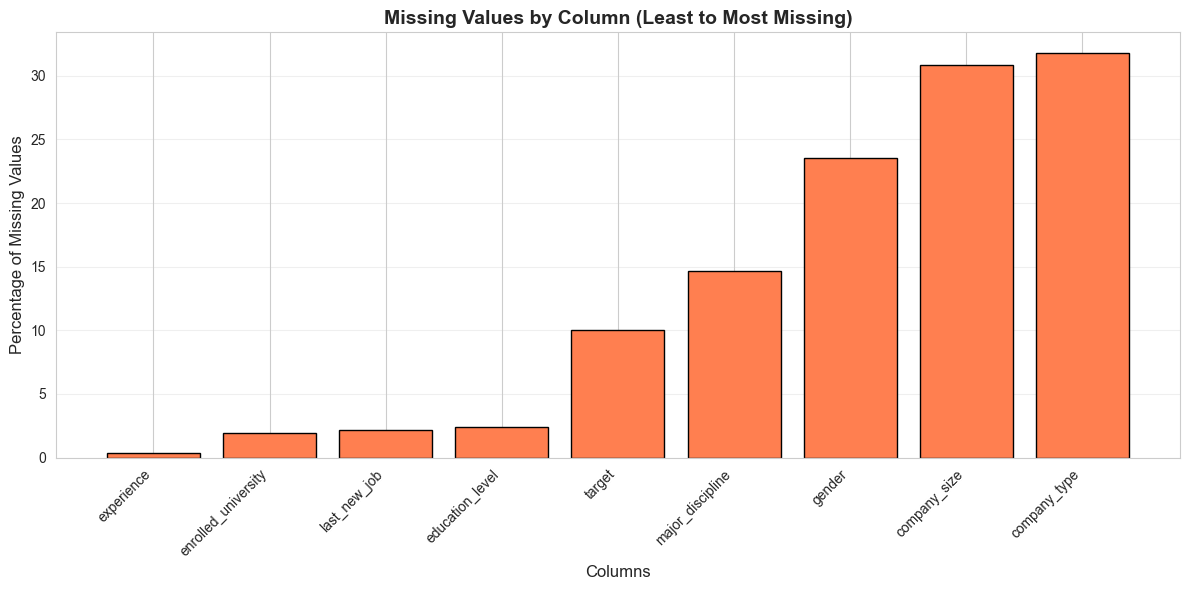

In [80]:
# Filter columns with missing values and sort ascending (least to most)
missing_cols = missing_percentages[missing_percentages > 0].sort_values(ascending=True)

# Create bar plot
plt.figure(figsize=(12,6))
plt.bar(range(len(missing_cols)), missing_cols.values, color='coral', edgecolor='black')
plt.xticks(range(len(missing_cols)), missing_cols.index, rotation=45, ha='right')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Percentage of Missing Values', fontsize=12)
plt.title('Missing Values by Column (Least to Most Missing)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### B.4 Missingno Visualization and Interpretation (5 pts)


#### B.4.1 MIssingno Bar Plot

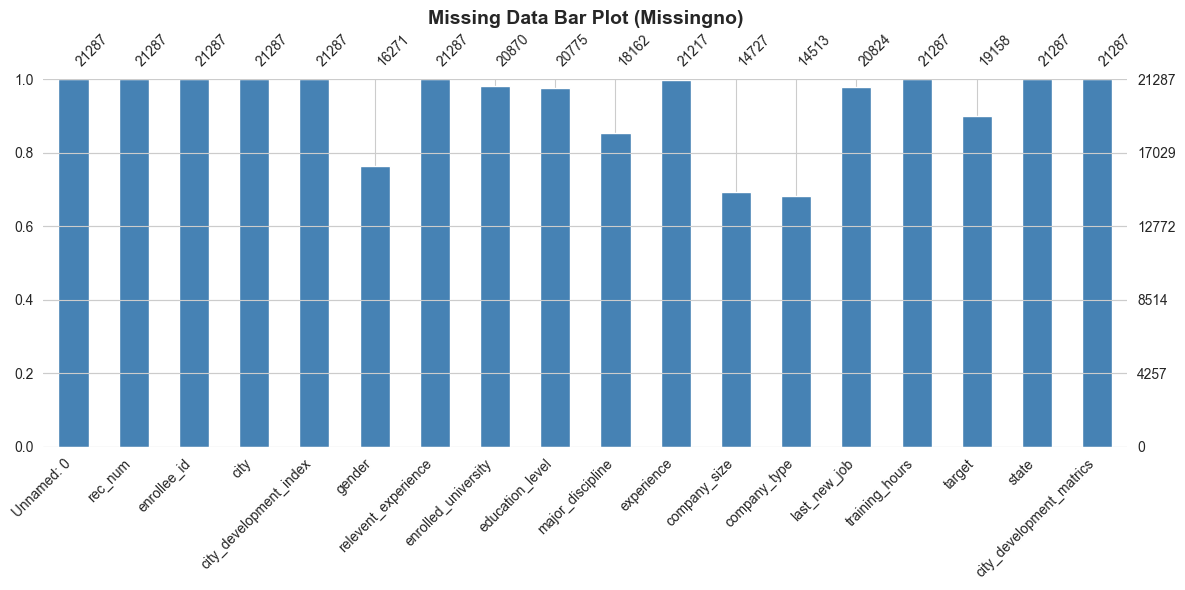

In [81]:
# Missingno Bar Plot
msno.bar(df, figsize=(12,6), fontsize=10, color='steelblue')
plt.title('Missing Data Bar Plot (Missingno)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### B.4.2 Missingno Matrix Plot (200 rows sample)

/var/folders/cw/_0h91lkx07vgv5sz7d023wpc0000gn/T/ipykernel_36565/3591834724.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


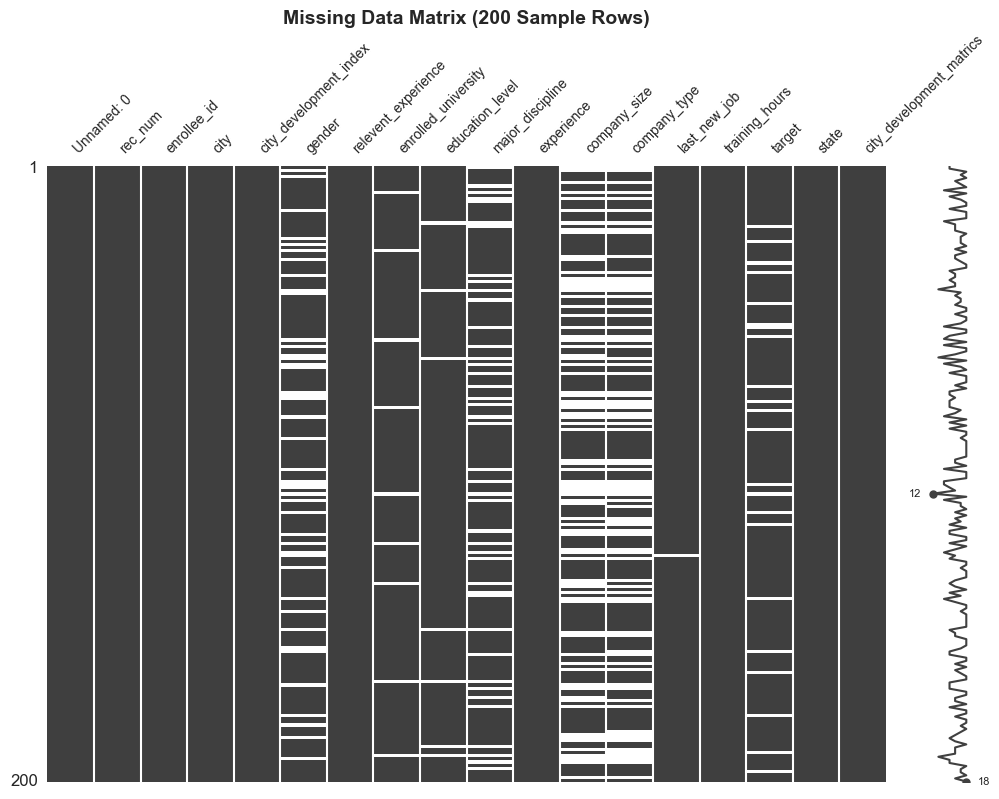

In [82]:
# Sample 200 rows for Matrix Plot
df_sample = df.sample(n=min(200, len(df)), random_state=42)

# Missingno Matrix Plot
msno.matrix(df_sample, figsize=(12,8), fontsize=10)
plt.title('Missing Data Matrix (200 Sample Rows)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### B.4.3 Missingno Heatmap

<function matplotlib.pyplot.show(close=None, block=None)>

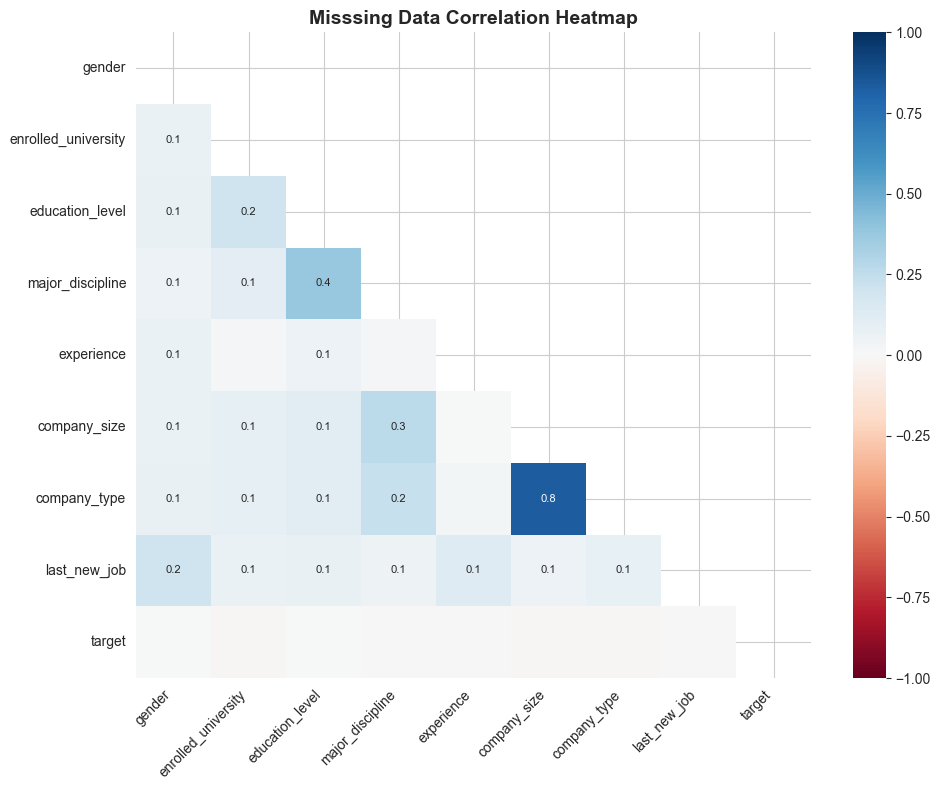

In [83]:
# Missingno heatmap (shows correlation of missingno between columns)
msno.heatmap(df, figsize=(10,8), fontsize=10)
plt.title('Misssing Data Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show

### B.4.4 Interpretation of Missing Data Patterns

** Analysis of Missing Values: **

1. Columns with Most Misssing Date: 
    - company_type: 31.82% missing (6,774 values) - Highest missing percentage
    - company_size: 30.82% missing (6,560 values) - Second highest
    - gender: 23.56% missing (5,016 values) - Nearly a quarter of candidates
    - major_discipline: 14.68% missing (3,125 values)
    - target: 10.00% missing (2,129 values) - Prediction Varible has 10% missing

2. Missing Data Patterns from Bar Plot: 
    - three distinct tiers of missingness are evident:
        - High tier (>20%): company_type, company_size, and gender from a cluster of heavily missing features
        - Medium tier (10-15%): major_discipline and target have moderate missingness
        - Low tier (<3%): education_level, last_new_job, enrolled_university, and experience have minimal missningness
    - Nine columns have complete data (0% missing): city, relevant_experience, training_hours, state, city_development_index, and ID Columns
    - Company-related features (company_type and company_size) have nearly identical missing percentages (~31%), suggesting they're likely missing together

3. Observations from Matrix Plot (200 Samle Rows):
    - the matrix plot revealed a clear vertical pattern where company_type and company_size missing values align perfectly, confirming they are missing simultaneously
    - Gender missing values appear scattered throughout the dataset rather than clustered in specific row ranges
    - many rows have multiple missing values, particularly in the company related and gender fields
    - The missing data does not appear to be entirely random - there are visable patterns suggesting systematic missingness
    - Some rows are nearly complete while others have significantly gaps arcoss multiple features

4. Correlation Heatmap Insights:
    - Strong positive correlation (close to 1.0) between company_size and company_type missingness indicates thee features are missing together
    - when candidates who are unemployed, self-employed, or prefer not to disclose employment details leave both company fields blank
    - Gender missingness shows weaker correlation with other features, suggesting its missing more independantly
    - Target variable missingness appears relatively independent of other features, which is concerning since its our predictions variable


5. Implication For Data Preprocessing

    Features requiring special attention:
    - company_type and company_size (>30% missing):
        - These should be handled together given their correlated missingness
        - Options like creating a "Not_Disclosed" category, treating them as a single feature indicating employment status disclosure, or evaluating whether dropping these features improves model performance.
    - gender (23.56% missing):
        - Create "Unknown" category rather than dropping rows, this might be intentional non-disclosure for privacy reasons.
    - target (10% missing):
        - This is a critical concern since this is our outcome variable. 
        - These  2129 rows cannot be used for supervised learning and must be removed from Training/Testing sets.
    - major_discipline (14.68% missing): 
        - Likely missing for candidates without formal higher education.
        - Impute with "No_Major" or "Unknown" category.

        




## C. Categorical Features Analysis (26 pts)

In this Section, we will analyze each categorical feature to understand
- Distribution of categories
- Fequency of different values
- Potential class imbalances 

### C.1 Value Counts for All Categorical Features (8 pts)
Displaying the frquency distribution for each categorical column

In [84]:
# Display value counts for each categorical feature
print("Value Counts for Categorical Feature:")
print("="*80)

for col in categorical_cols:
    print(f"\n{col.upper()}")
    print("-"*80)
    print(df[col].value_counts())
    print()

Value Counts for Categorical Feature:

CITY
--------------------------------------------------------------------------------
city
city_103    4828
city_21     3020
city_16     1701
city_114    1491
city_160     958
            ... 
city_166       4
city_111       3
city_129       3
city_171       2
city_140       1
Name: count, Length: 123, dtype: int64


GENDER
--------------------------------------------------------------------------------
gender
Male      14681
Female     1375
Other       215
Name: count, dtype: int64


RELEVENT_EXPERIENCE
--------------------------------------------------------------------------------
relevent_experience
Has relevent experience    15316
No relevent experience      5971
Name: count, dtype: int64


ENROLLED_UNIVERSITY
--------------------------------------------------------------------------------
enrolled_university
no_enrollment       15336
Full time course     4192
Part time course     1342
Name: count, dtype: int64


EDUCATION_LEVEL
-------------

### C.2 Bar Plot for all Categorical feautures (9 pts)
Visualizing the distribution of each categorical feature using bar plots.

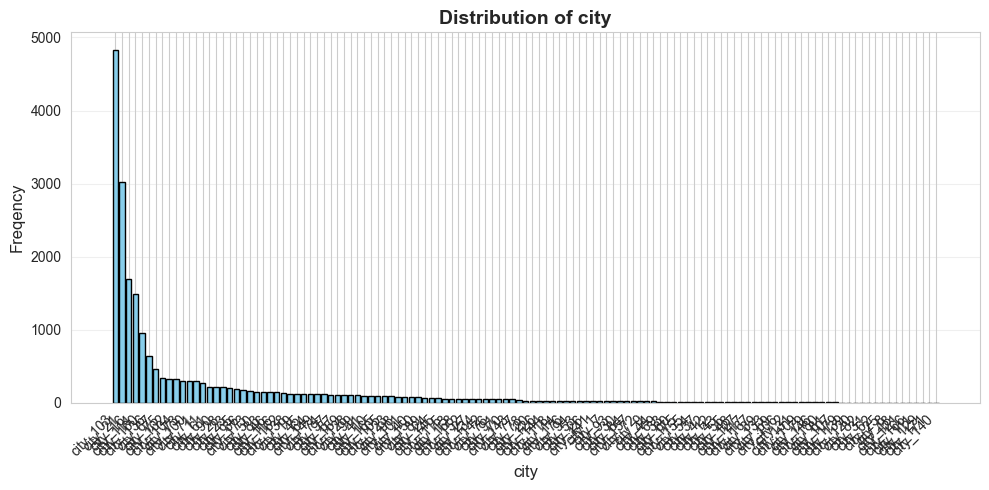

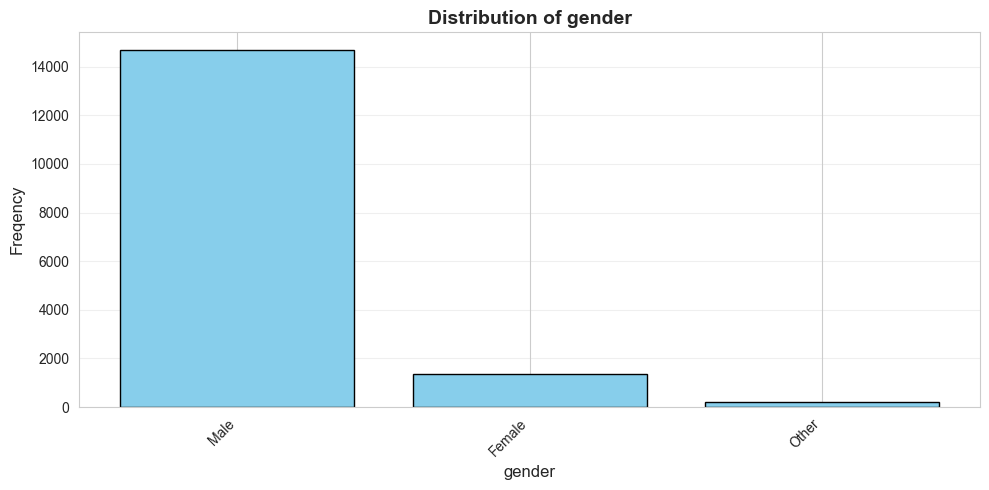

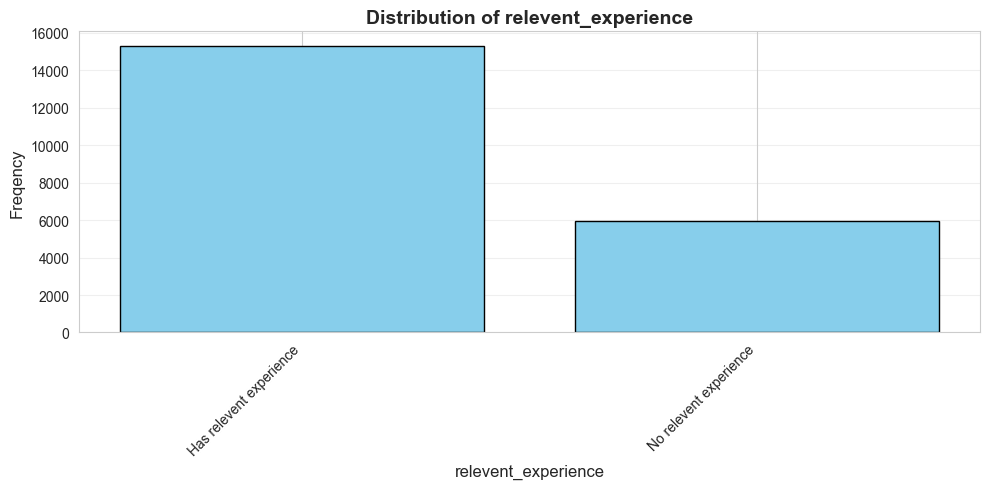

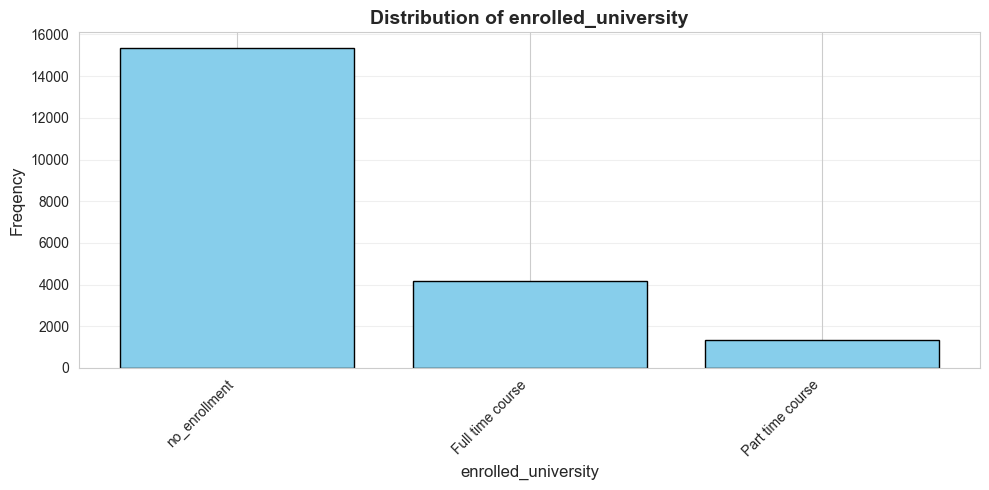

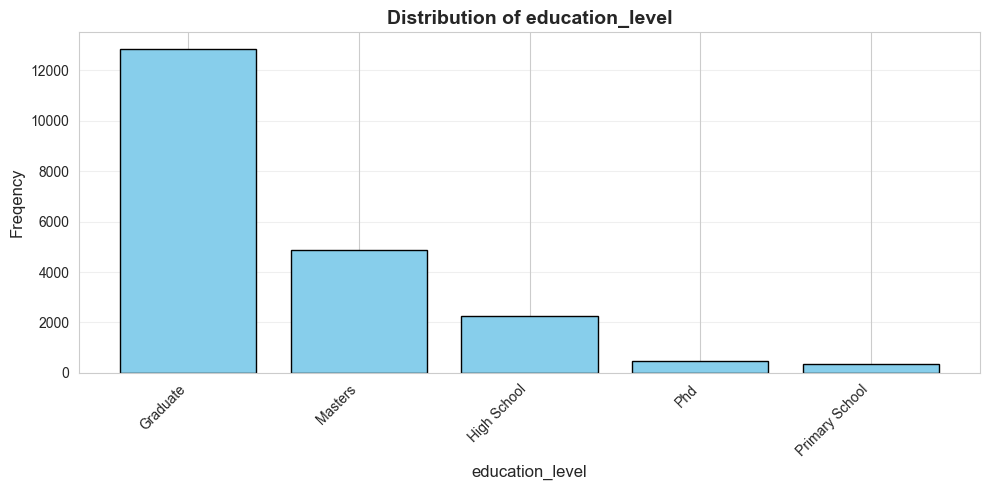

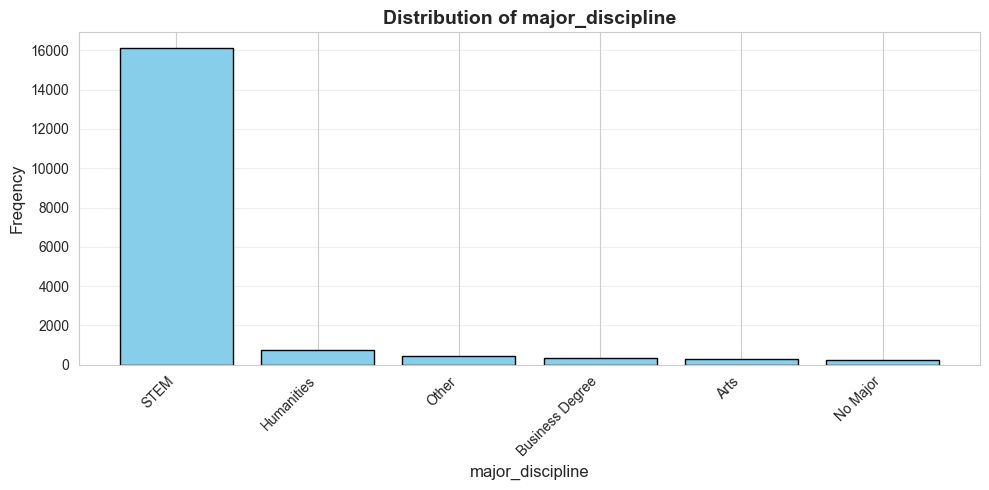

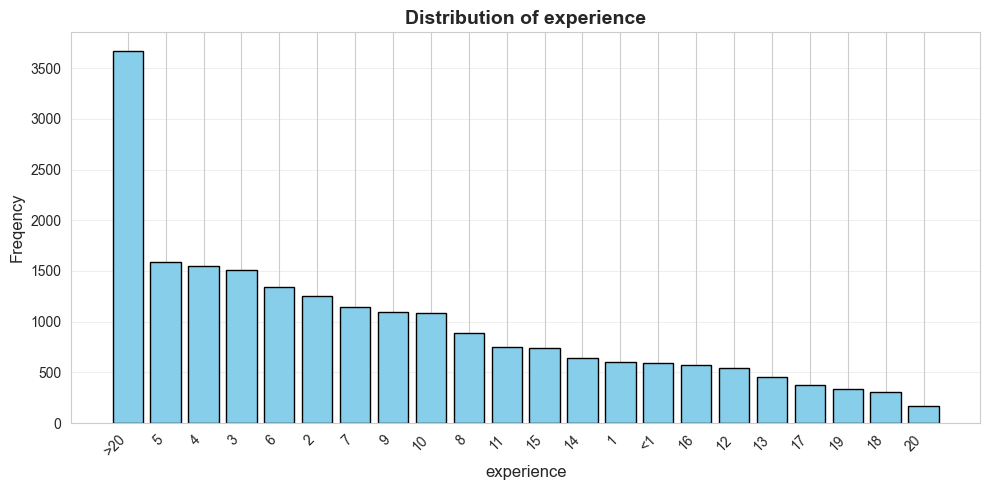

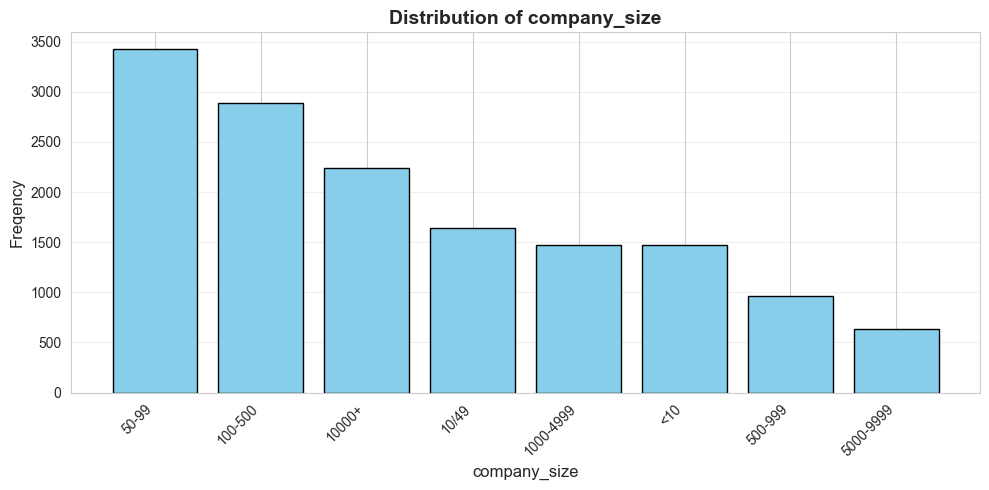

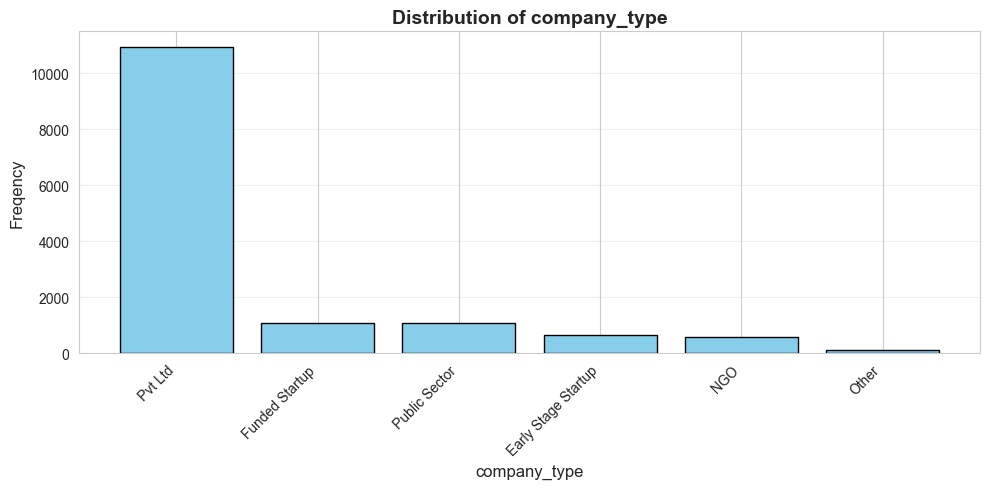

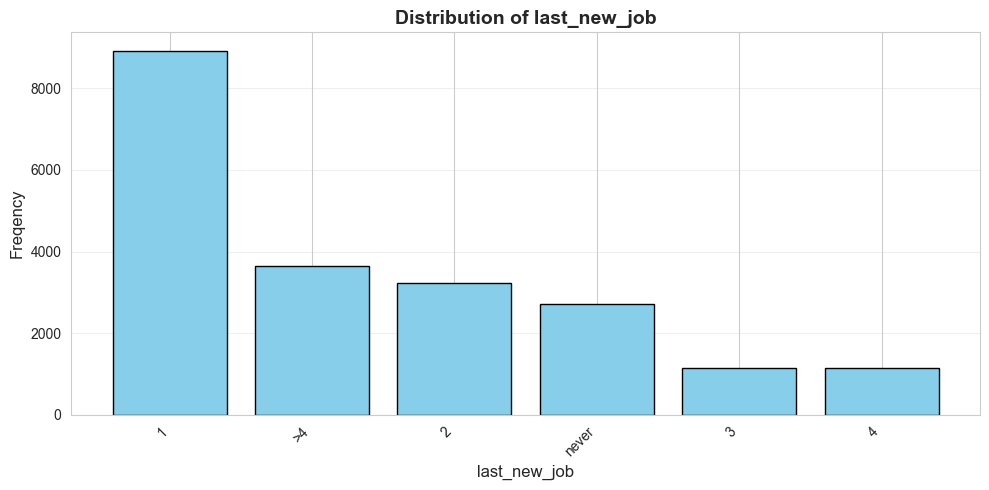

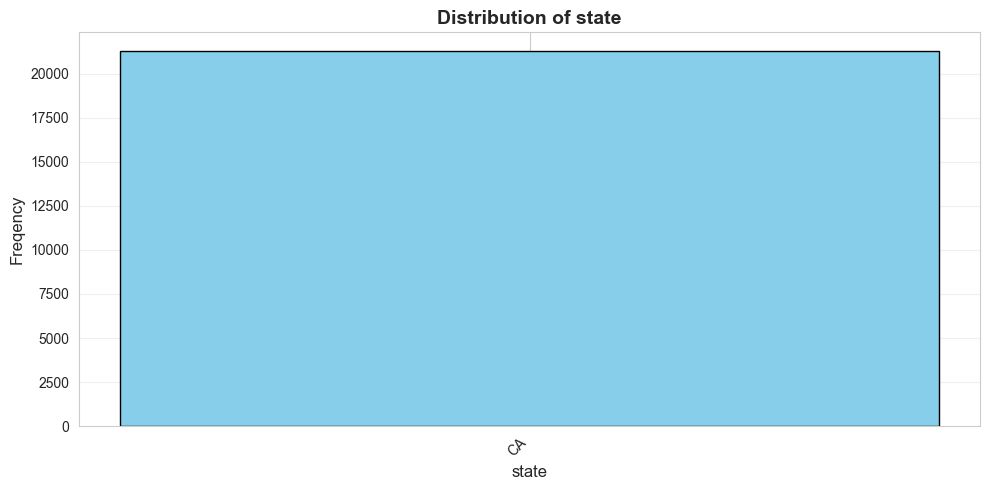

In [85]:
# Create bar plots for all categorical feature
for col in categorical_cols:
    plt.figure(figsize=(10,5))

    # Get value Counts
    value_counts = df[col].value_counts()

    # Create bar plot
    plt.bar(range(len(value_counts)), value_counts.values, color='skyblue', edgecolor='black')
    plt.xticks(range(len(value_counts)), value_counts.index, rotation=45, ha='right')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Freqency', fontsize=12)
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


### C.3 Countplots of Categorical Features Against Target (9 pts)
Analyzing how the target variable (job change likelihood) varies across different categories using stacked bar plots showing proportions.

<Figure size 1200x500 with 0 Axes>

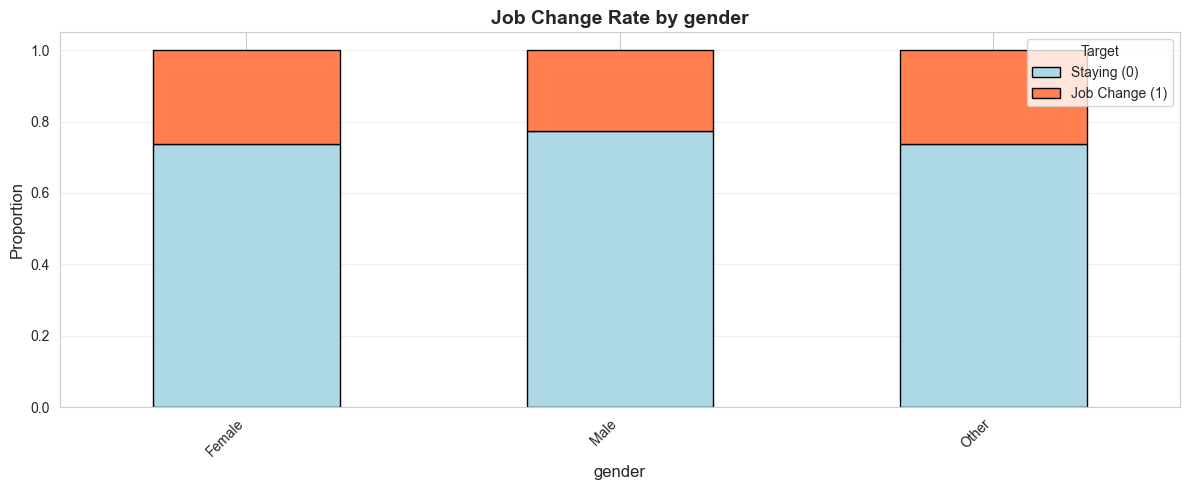

<Figure size 1200x500 with 0 Axes>

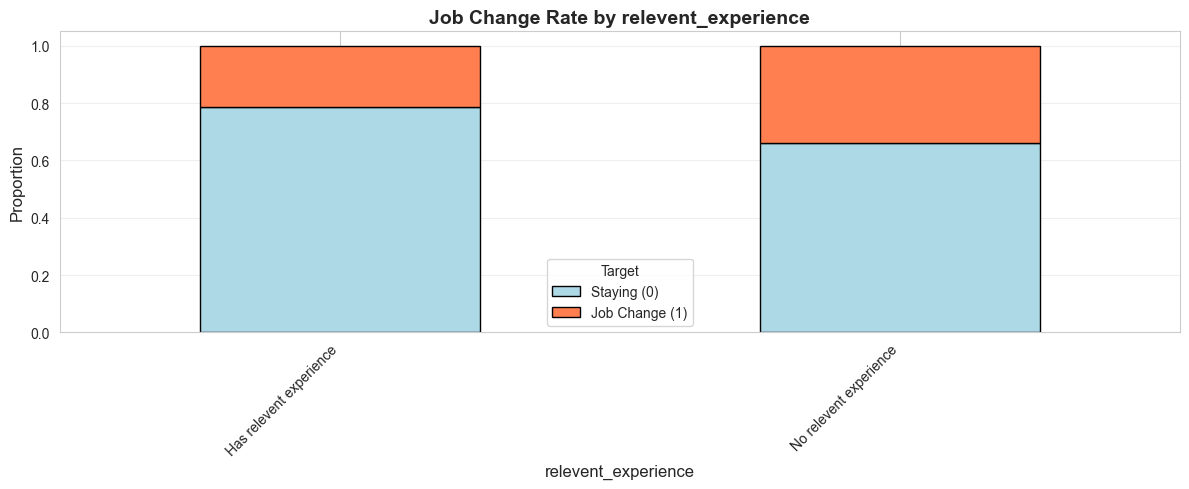

<Figure size 1200x500 with 0 Axes>

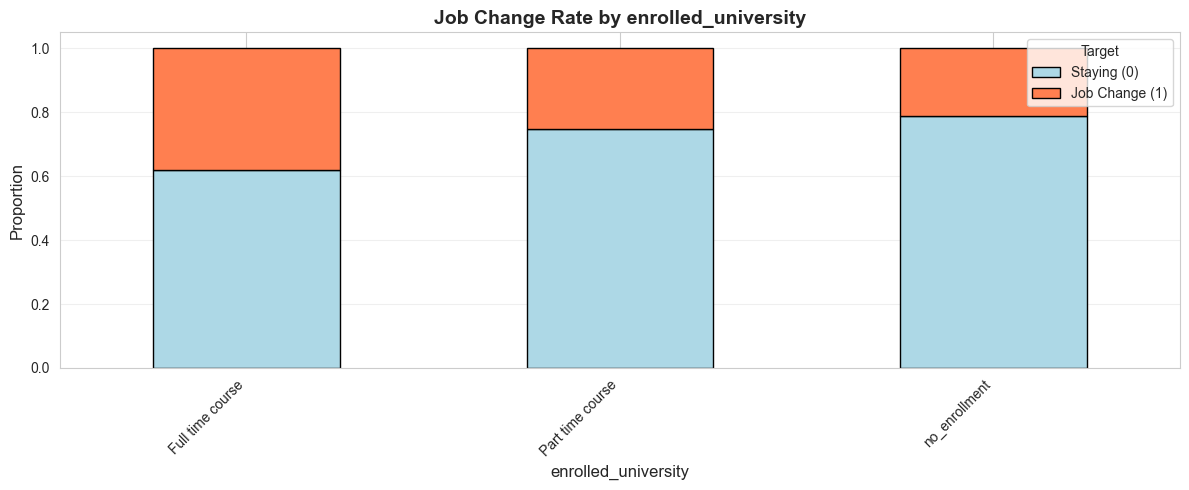

<Figure size 1200x500 with 0 Axes>

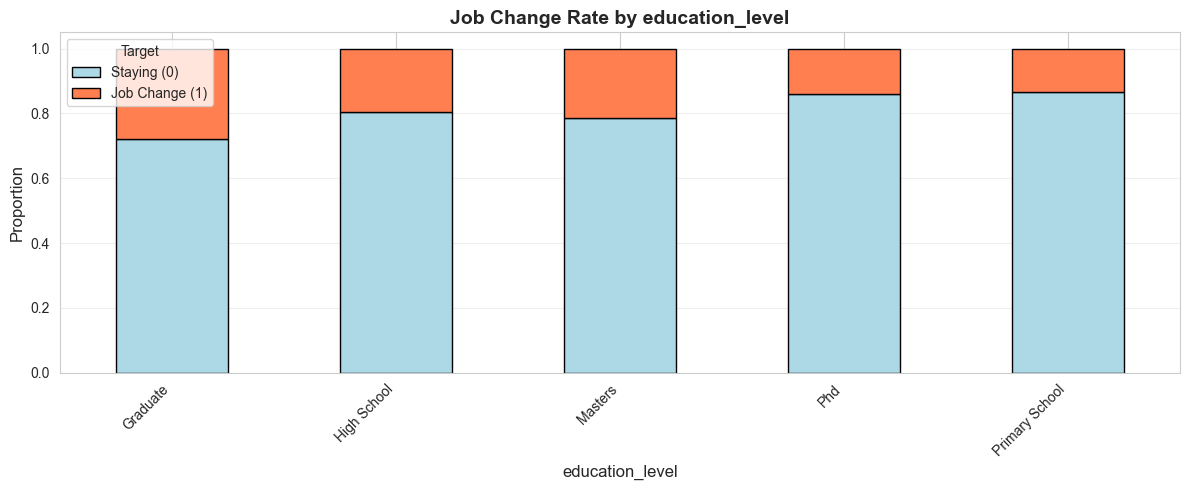

<Figure size 1200x500 with 0 Axes>

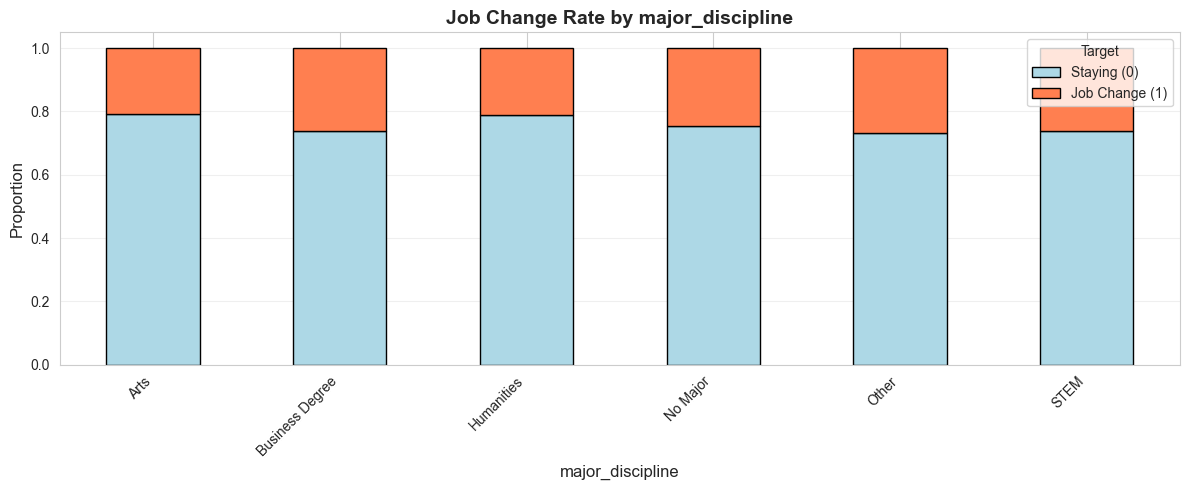

<Figure size 1200x500 with 0 Axes>

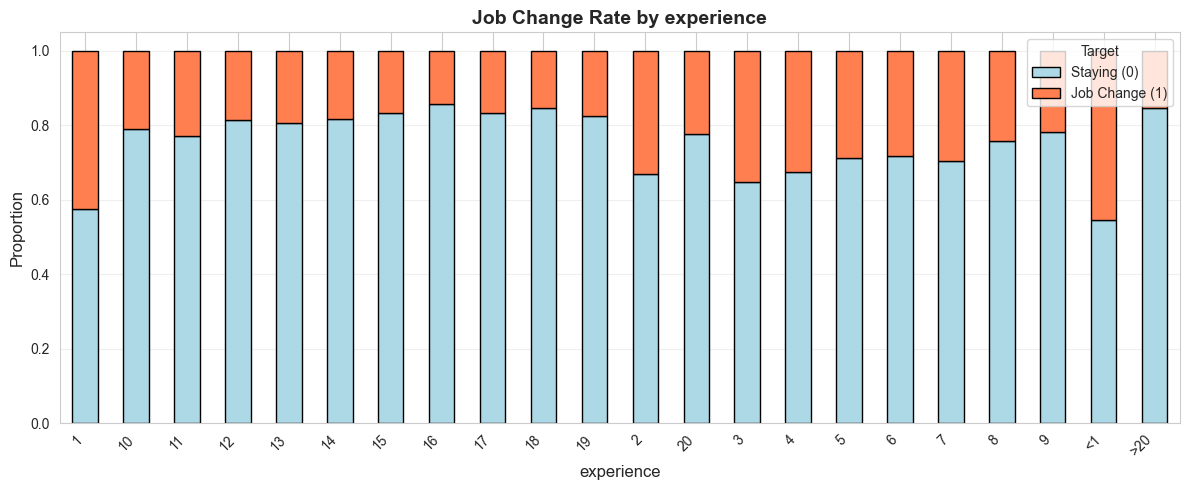

<Figure size 1200x500 with 0 Axes>

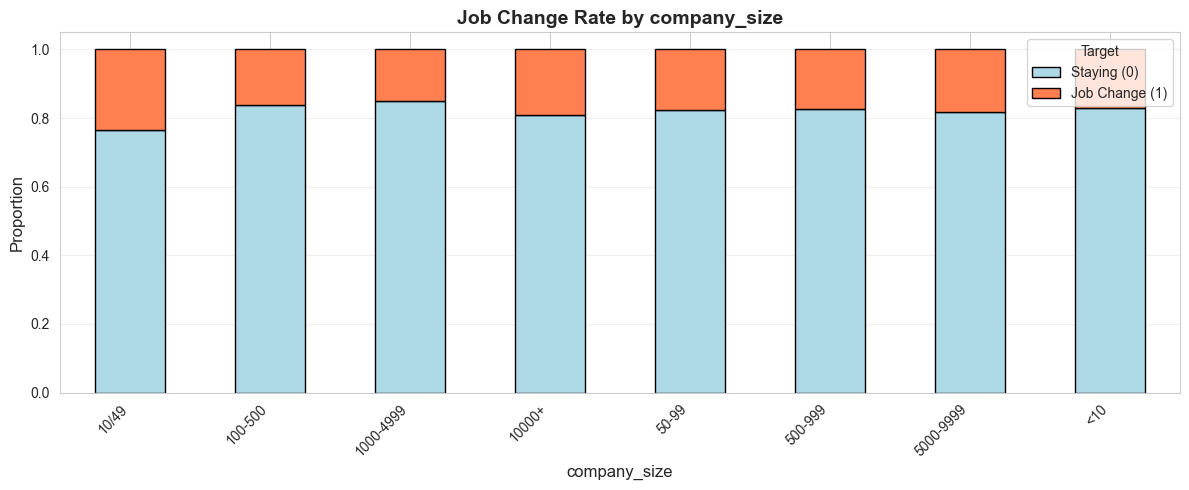

<Figure size 1200x500 with 0 Axes>

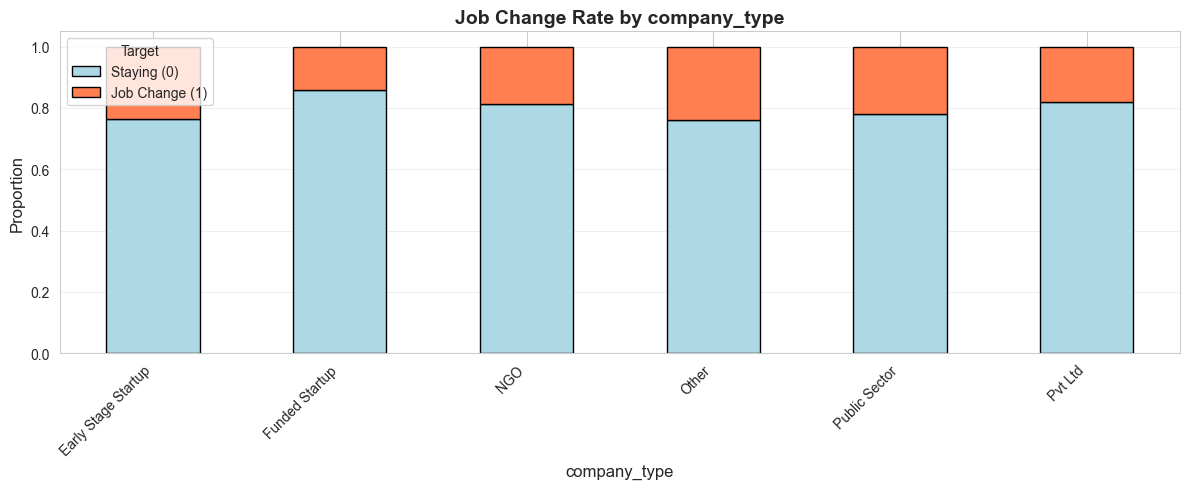

<Figure size 1200x500 with 0 Axes>

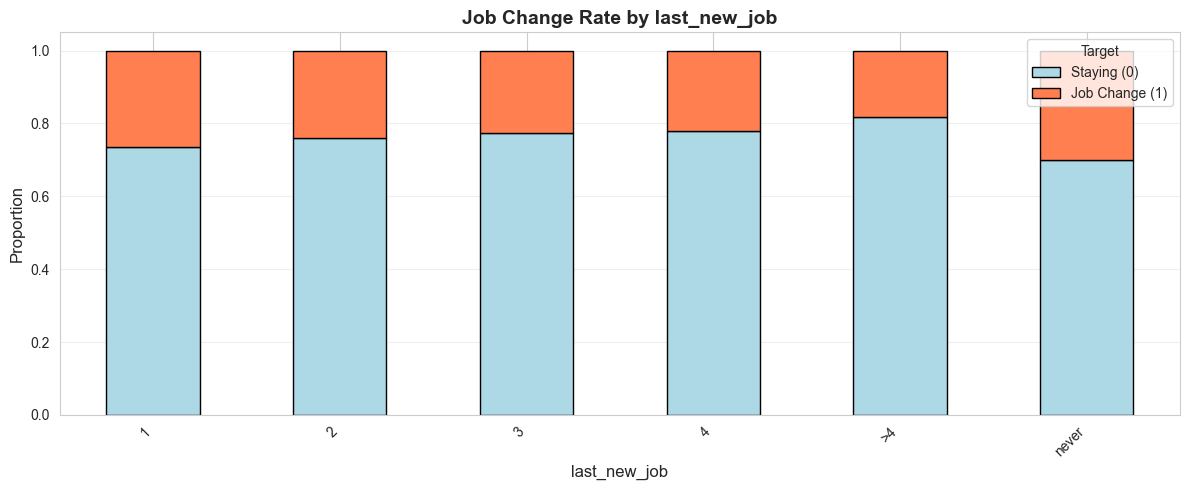

In [86]:
# Create percentage-based plots showings target distribution for each category
categorical_to_plot = [col for col in categorical_cols if col not in ['city', 'state']]

for col in categorical_to_plot:
    # calculate percentage of job changes for each category
    grouped = df.groupby(col)['target'].value_counts(normalize=True).unstack()

    # Handle missing target values
    if grouped is not None and not grouped.empty:
        plt.figure(figsize=(12,5))

        # Create stacked bar plot
        grouped.plot(kind='bar', stacked=True, color=['lightblue', 'coral'], figsize=(12,5), edgecolor='black')

        plt.xlabel(col, fontsize=12)
        plt.ylabel('Proportion', fontsize=12)
        plt.title(f'Job Change Rate by {col}', fontsize=14, fontweight='bold')
        plt.legend(title='Target', labels=['Staying (0)', 'Job Change (1)'])
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()


### C.4 Interpretation of Categorical Features
Key Observations from categorical Feature analysis
1. Relevant Experience
- Candidates with relevant experience show different job change pattern compared to those without
- This appears to be a strong differentiator for the target variable
2. Education Level:
- Graduate-level education is the most common in the datasheet
- Different education levels show varying biases for job change
3. Enrolled University:
- Mix of candidates currently enrolled, not enrolled, or in part time programs
- Enrollment status may correlate with job change intent
4. Company Characteristics:
- Significant missing data noted (from Section B: ~31% missing)
- Among avaliable data, company size and type show distinct patterns in job change rates
5. Experience Distribution
- Wide range: from <1 year to >20 years
- Experience levels show clear patterns in job seeking behavior
- Will be categorized further in Section G
6. Gender:
- Predominantly male dataset (noted in value counts)
- Small Sample sizes for "Other" and "Female" categories
7. Implications for Modeling:
- relevant_experience is likely a strong predictor
- education_level and major_discipline provide useful signal
- High-cardinality features (city with 123 categories) need special encoding
- Missing company data may need "Unknown" category rather than imputation
- Target class imbalance (75% staying, 25% looking) requires addressed in modeling


## D. Numerical Features Analysis (16 pts)
In this section, we will analyze each numerical feature to understand
- Distribution of shapes (normal, skewed, uniform)
- Presence of outliers
= Range and spread of values

### D.1 Histogram for All Numerical Features (5 pts)
Visualizing the distribution of each numerical feature using histograms.

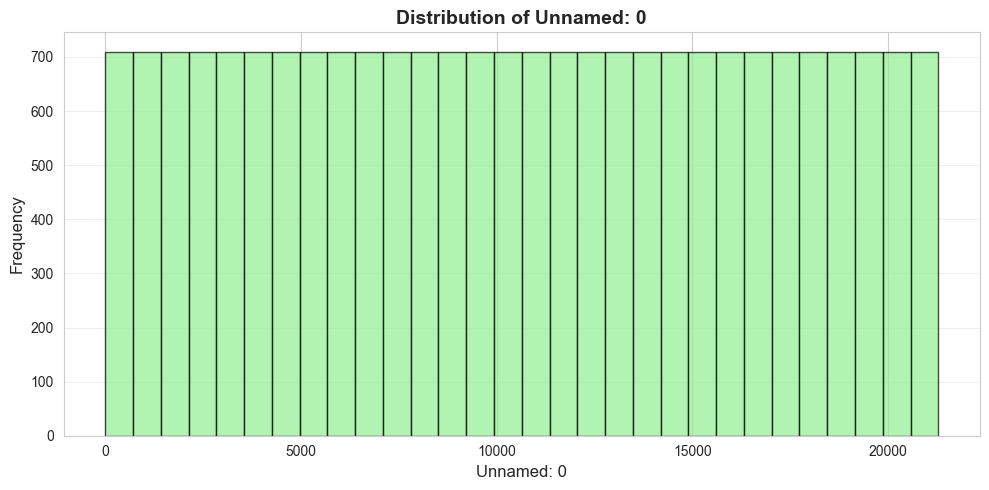

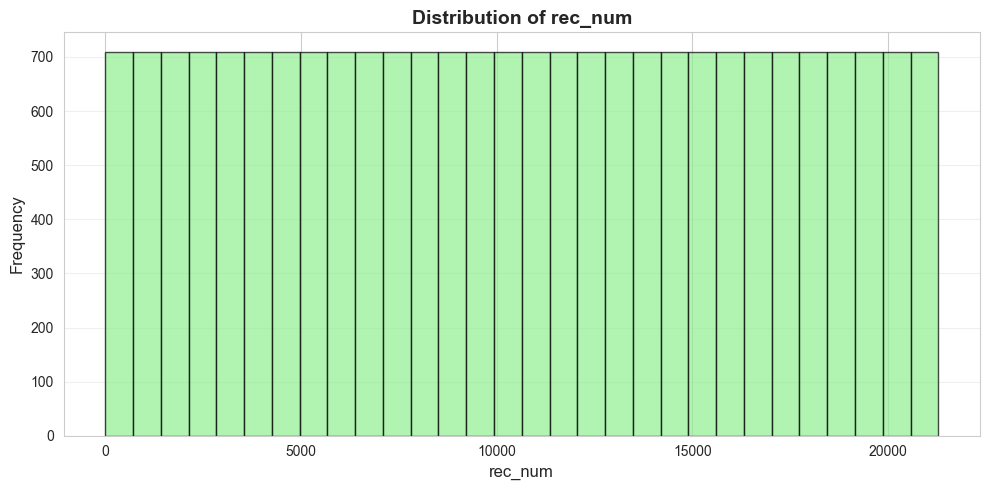

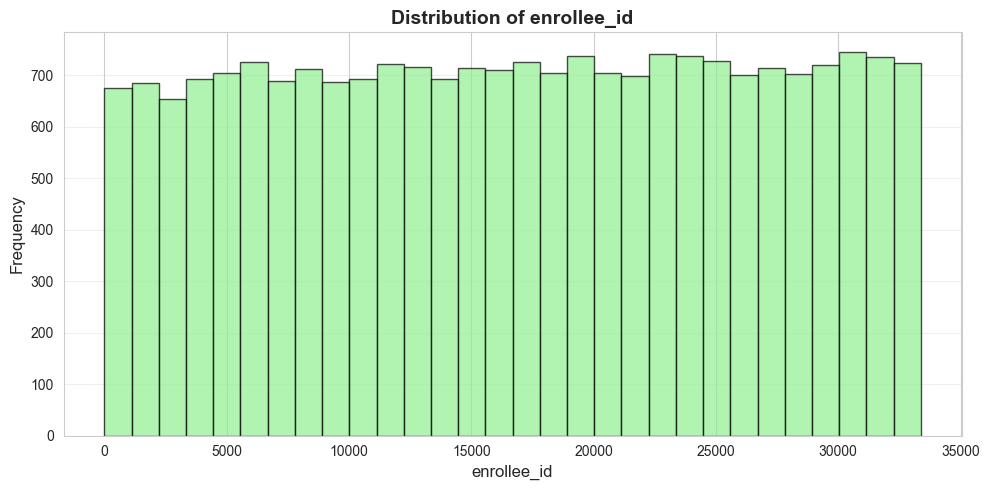

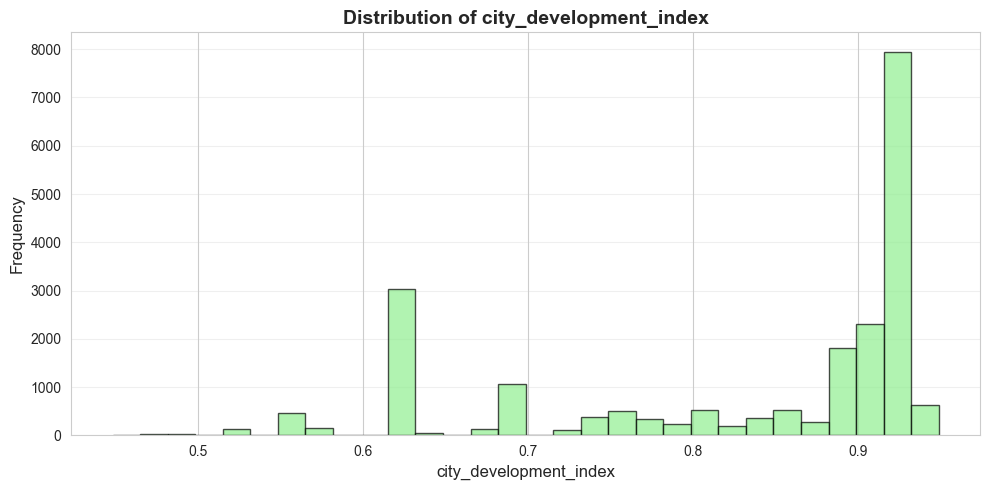

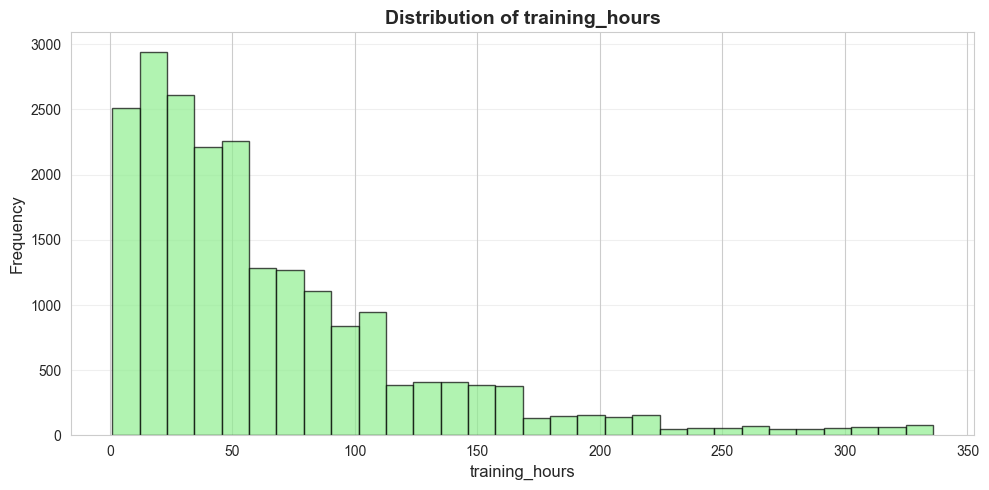

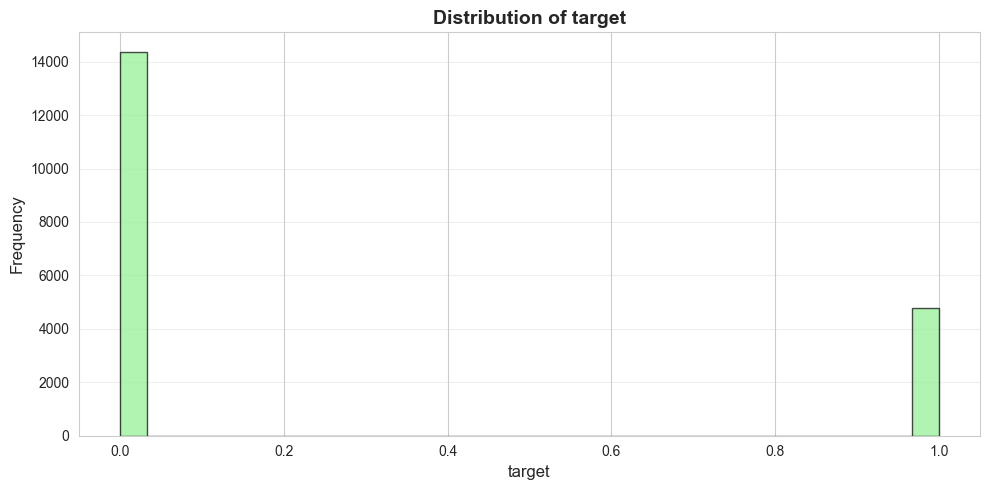

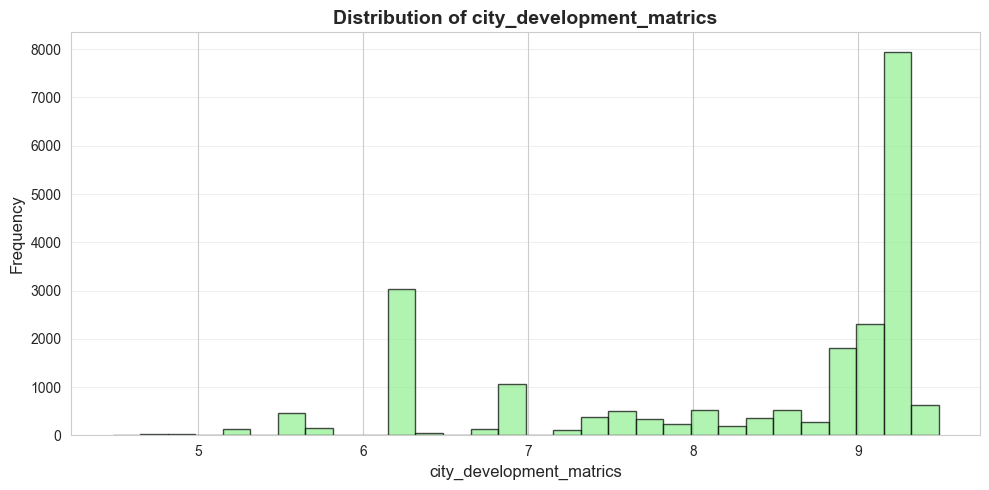

In [87]:
# Create histograms for all numerical features
for col in numerical_cols:
    plt.figure(figsize=(10,5))

    # Create histogram
    plt.hist(df[col].dropna(), bins=30, color= 'lightgreen', edgecolor='black',alpha=0.7)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


### D.2 Distribution Plots (Distplot) for Numerical Features (5 pts)
Using seaborn displot to visualize distributions with kernal density estimation (KDE)

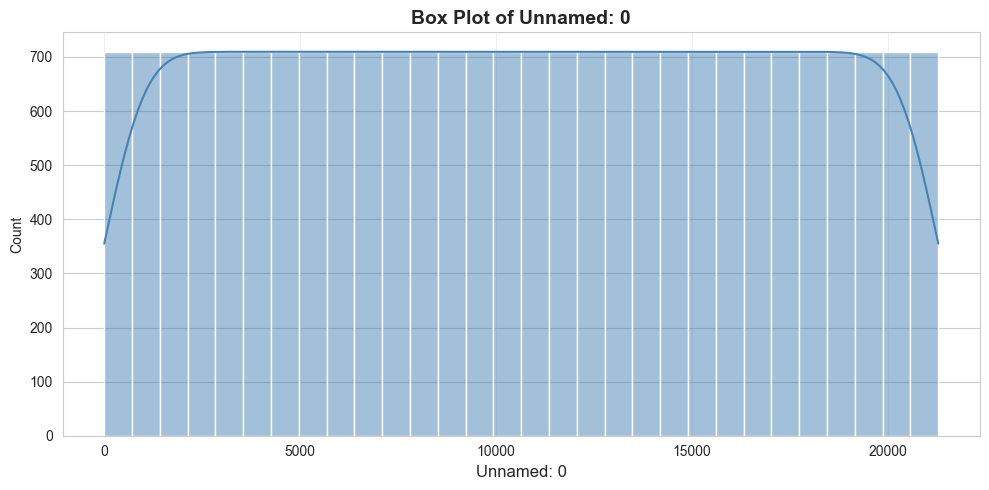

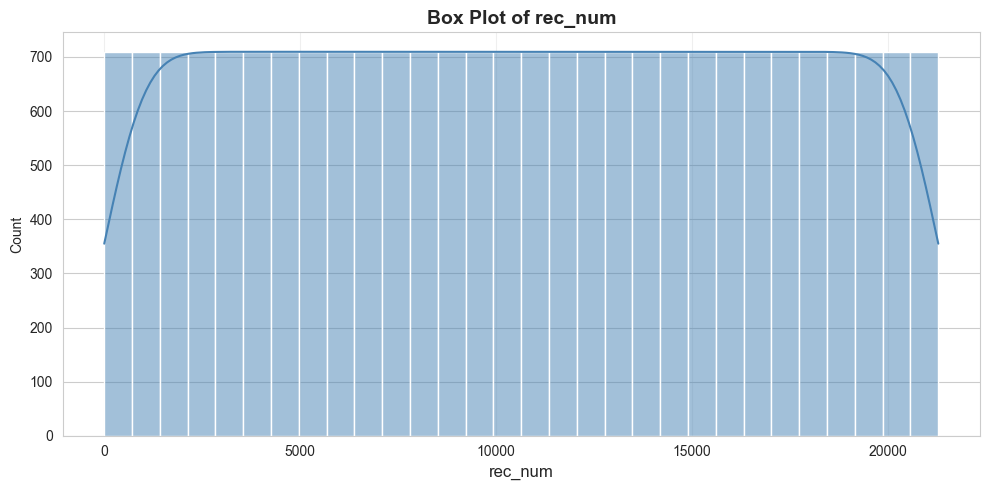

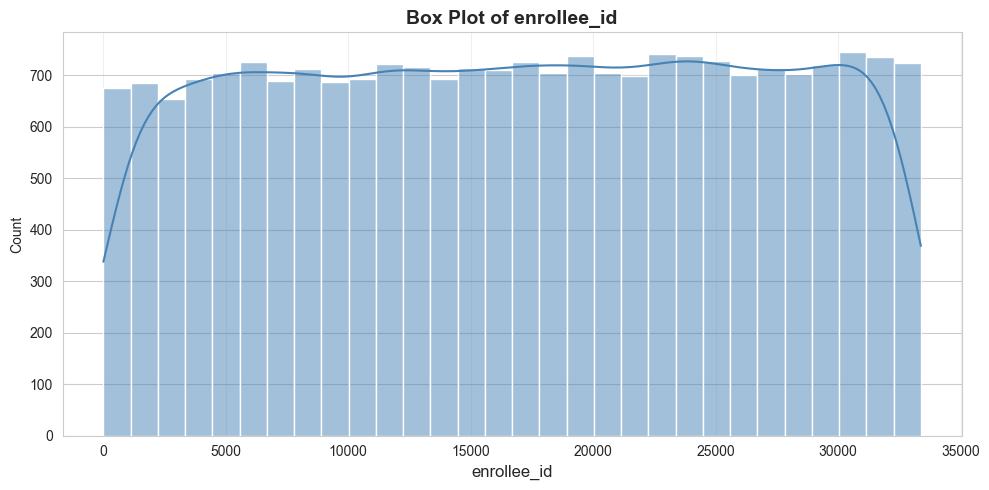

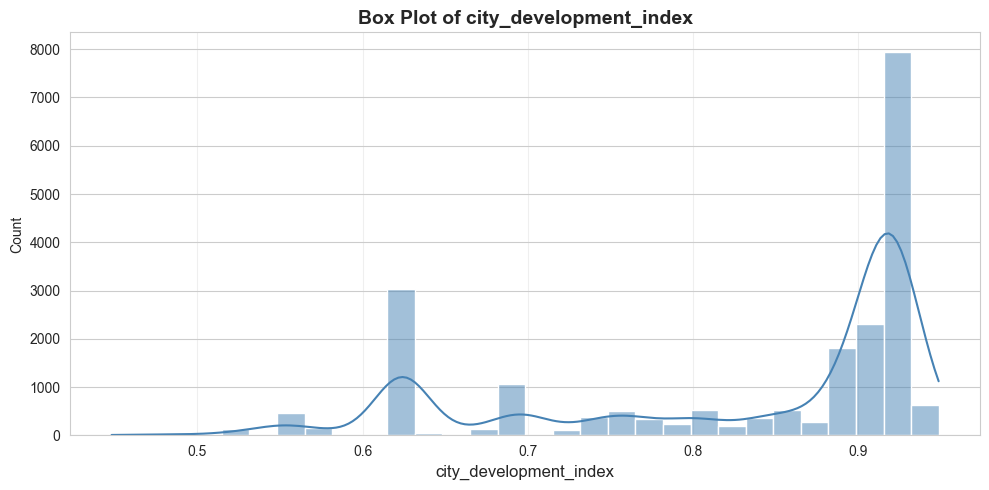

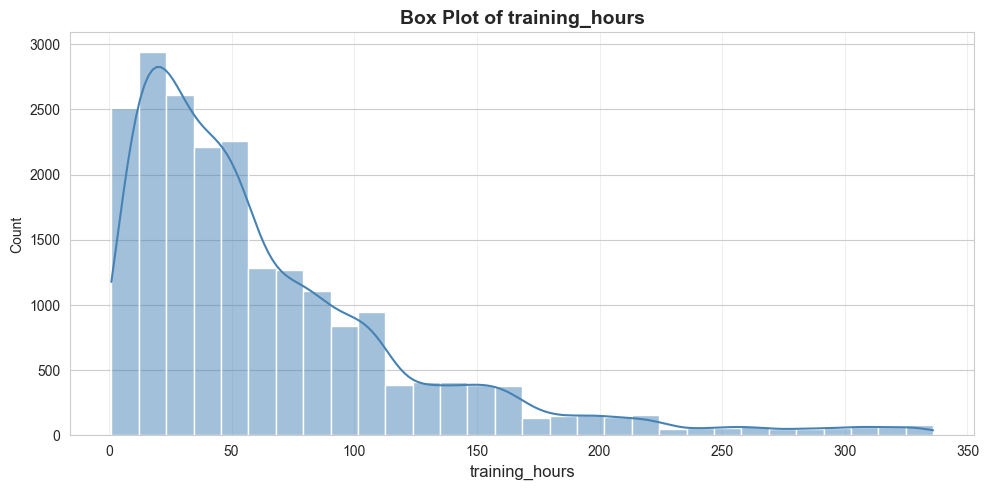

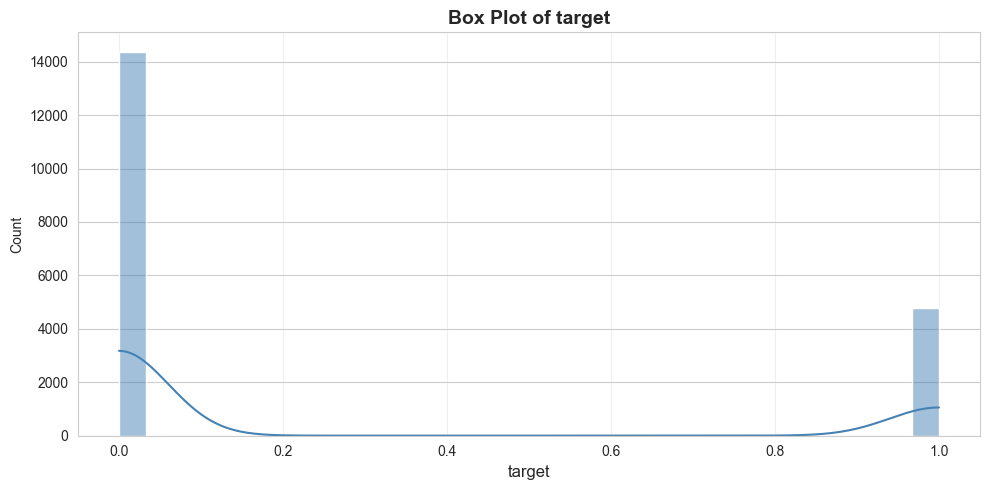

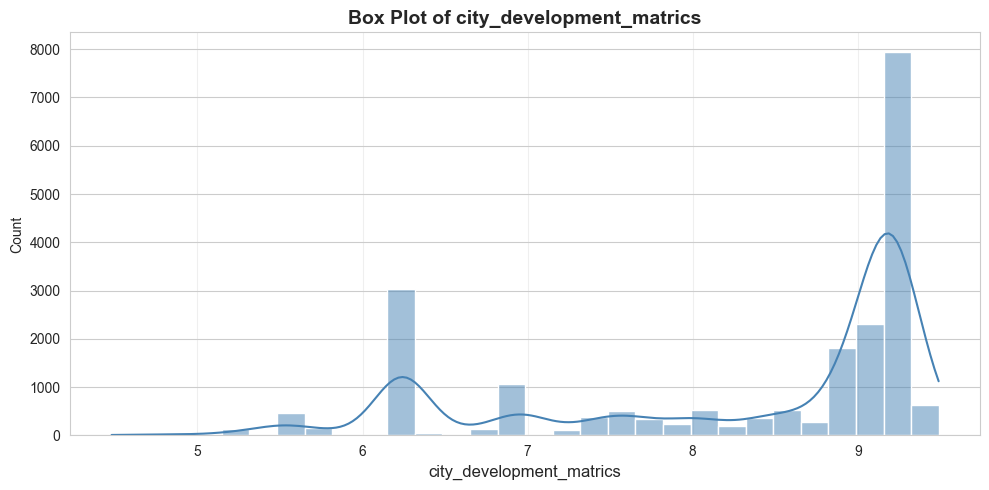

In [88]:
# Create box plots for all numerical features
for col in numerical_cols:
    plt.figure(figsize=(10,5))

    # Create displot (histogram + KDE)
    sns.histplot(df[col].dropna(), kde=True, color='steelblue', bins=30)

    plt.xlabel(col, fontsize=12)
    plt.title(f'Box Plot of {col}', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### D.3 Interpretation of Numerical Features (6 pts)
Key observation from numerical feature distributions:
1. ID columns (Unnamed: 0, rec_num, enrollee_id):
- These show uniform or sequential distribution
- No predictive value - should be removed before modeling
- rec_num and Unnamed: 0 are identical (perfect correlation confirmed in Section E)
2. city_development_index:
- Left-Skewed distribution (most cities have high development indices around 0.9)
- Range: 0.448 to 0.949
- Few Cities with low development indices (potential outliers noted in Section G)
- This is our strongest numerical predictor (correlation -0.34 with target from Section E)
3. city_development_matrics:
- Identical to city_development_index (just scaled by 10)
- Perfect correlation of 1.0 - redundant feature
- Should be removed before modeling
4. training_hours:
- Strongly right-skewed distribution (confirmed by histogram and distplot)
- Mean (65.4 hours) > Median (47 hours) indicates right skew
- Range: 1 to 336 hours with long tail
- Outliers present (5.16% above upper bound from Section G)
- May Benefit from log transformation for linear models
- The extreme values (200+ hours) are valid data representing intensive training
5. target:
- Binary variable (0 and 1)
- Approximately 75% staying (0), 25% looking for job change (1)
- Class imbalance present - will need to be addressed in modeling
- 10% missing values (2,129 rows) must be removed for supervised learning
6. Distribution Patterns:
- Most features are NOT normally distributed 
- Right skew in training_hours suggests candidates with extreme training investment
- left skew in city_development_index suggests most candidates from developed cities
- Binary and Categorical-like distributions in some numerical features
7. Implications for Modeling
- Drop redunant features: city_development_matrics, Unnamed:0, rec_num
- Tree based models will handle skewness and outliers naturally 
- Address class imbalance in target variable (25% positive class)
- Remove 2,129 rows where target is missing
- No major scaling needed for tree-based models, but standardization recommeded for distance-based models

## E. Correlation Analysis (15 pts)
In this section, we will analyze correlations between numerical features to understand:
- Which features are strongly related
- Potential multicollinearity issues
- Relationships that might be useful for modeling

### E.1 Correlation Matrix (2 pts)
Computing the correlation matrix for all numerical features.

In [89]:
# Calculate correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix:")
print("="*80)
display(correlation_matrix)

Correlation Matrix:


,Unnamed: 0,rec_num,enrollee_id,city_development_index,training_hours,target,city_development_matrics
Unnamed: 0,1.000000,1.000000,-0.000458,-0.004157,0.002554,-0.000077,-0.004157
rec_num,1.000000,1.000000,-0.000458,-0.004157,0.002554,-0.000077,-0.004157
enrollee_id,-0.000458,-0.000458,1.000000,-0.040916,0.001222,0.049475,-0.040916
city_development_index,-0.004157,-0.004157,-0.040916,1.000000,-0.000556,-0.341665,1.000000
training_hours,0.002554,0.002554,0.001222,-0.000556,1.000000,-0.021577,-0.000556
target,-0.000077,-0.000077,0.049475,-0.341665,-0.021577,1.000000,-0.341665
city_development_matrics,-0.004157,-0.004157,-0.040916,1.000000,-0.000556,-0.341665,1.000000


### E.2 Correlation Heatmap (3 pts)
Visualizing the correlation matrix using a heatmap with annotatons.

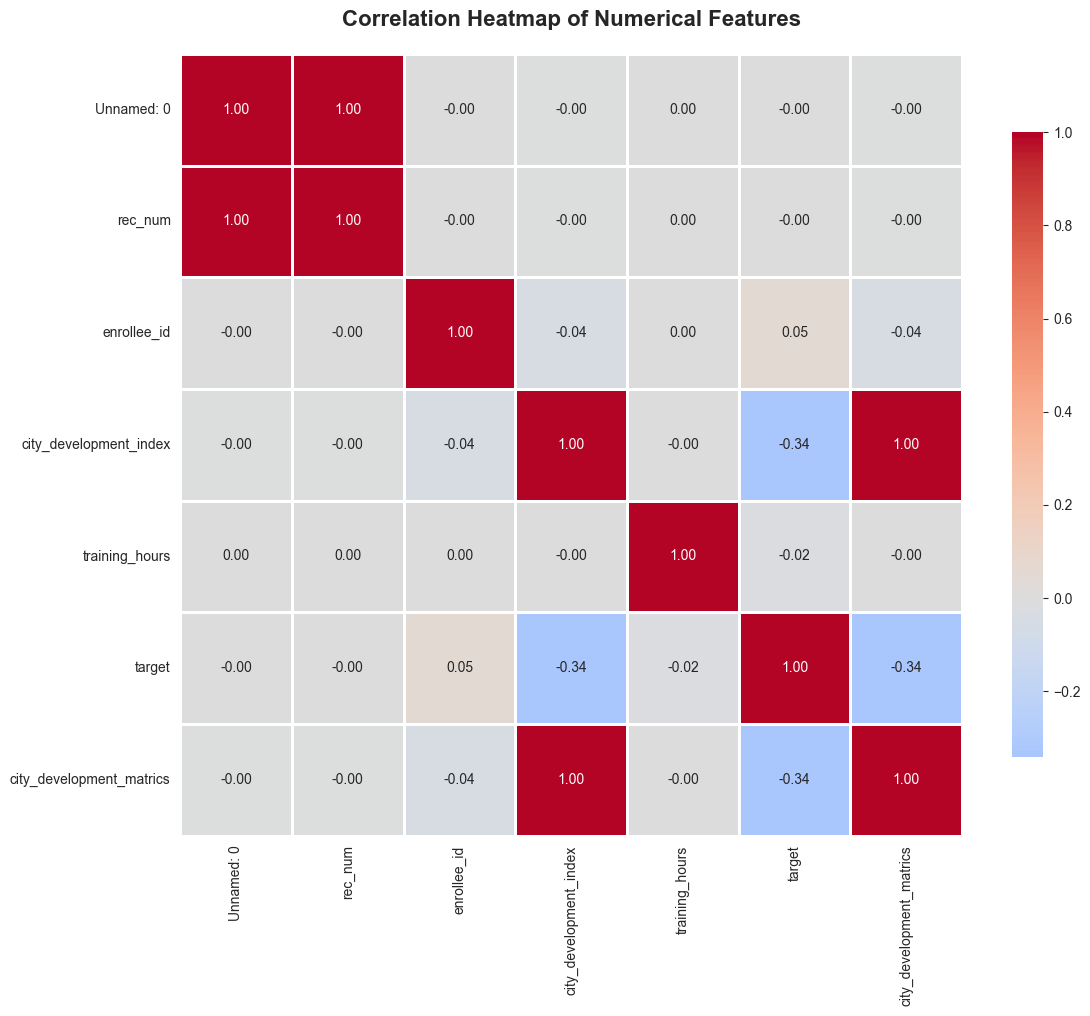

In [90]:
# create correlation Heatmap
plt.figure(figsize=(12,10))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### E.3 Interpretation of Correlation Results (2 pts)
Analysis of the correlation patterns observed in the heatmap:

1. Perfect Correlation (1.00):
    - city_development_index and city_development_matrics: 1.00 correlation -these are redundant features (one is simply 10x the other)
    - Unnamed: 0 and rec_num: 1.00 correlation - both are sequential row indentifiers with no predictive value

2. Strong Correlations (> 0.7 or < -0.7):
    - No strong correlations exist between meaningful features in this dataset
    - This indicates that most features provide independent information

3. Moderate Correlations (0.3 to 0.7 or -0.3 to -0.7):
    - target and city_development_index: -0.34 correlation (negative)
    - target and city_development_matrics: -0.34 correlation (negative as well since these features are identical)
    - This suggests candidates from less developed cities are MORE likely to look for job changes

4. Weak Correlations (-0.3 to 0.3):
    - Most feature pairs show very weak correlations (close to 0)
    - training_hours shows almost no correlation with any other features
    - enrollee-id shows weak correlations with everything (as expected for an ID)
    - this independence between features is generally good for modeling

5. Key Observations for Target Variable
    - city_development_index has the strongest correlation with target (-0.34)
    - Candidates from citues wth lower development indices are more likely to seek job changes
    - training_hours has almost no linear correlation with target (-0.02)
    - ID columns have no meaningful correlation with target (as expected)

6. Implication of Modeling:
    - city_development_matrics should be dropped (redundant with city_development_index)
    - ID columns (Unnamed; 0, rec_num, enrolled-id) must be removed before modeling
    - No multicollinearity concerns among meaningful features (all correlations <0.7)
    - The weak correlations suggest we may need to explore non-linear relationships
    - City development level appears to be the most predictive numerical feature

### E.4 Focused Correlation Heatmap (4 pts)
Creating a focused heatmap with the most relevant features (excluding ID columns) for better visibility of important correlations.

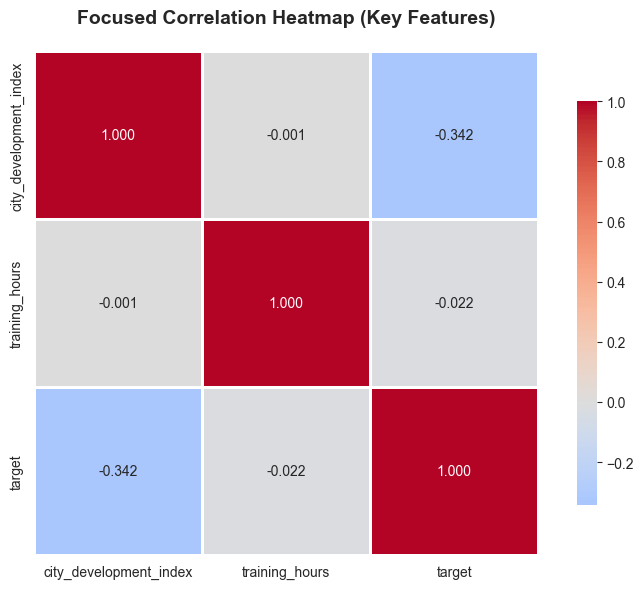


Key OBservations from focused Heatmap
city_development_index ↔ target: -0.342
training_hours ↔ target: -0.022
city_development_index ↔ training_hours: -0.001


In [91]:
# create focused heatmap with meaningful features (Exclude ID columns)
focused_features = ['city_development_index', 'training_hours', 'target']
focused_corr = df[focused_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(focused_corr, annot=True, fmt='.3f',cmap='coolwarm', center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8})

plt.title('Focused Correlation Heatmap (Key Features)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nKey OBservations from focused Heatmap")
print("="*80)
print(f"city_development_index ↔ target: {focused_corr.loc['city_development_index', 'target']:.3f}")
print(f"training_hours ↔ target: {focused_corr.loc['training_hours', 'target']:.3f}")
print(f"city_development_index ↔ training_hours: {focused_corr.loc['city_development_index', 'training_hours']:.3f}")

### E.5 Scatter Plots Showing Relationships with Target (4 pts)
Visualizing how numerical features relate to the target variable using scatter plots. Since target is binary (0 or 1), we'll show seperate distributions for each target class.

Creating scatter plots for 2 numerical features vs target..


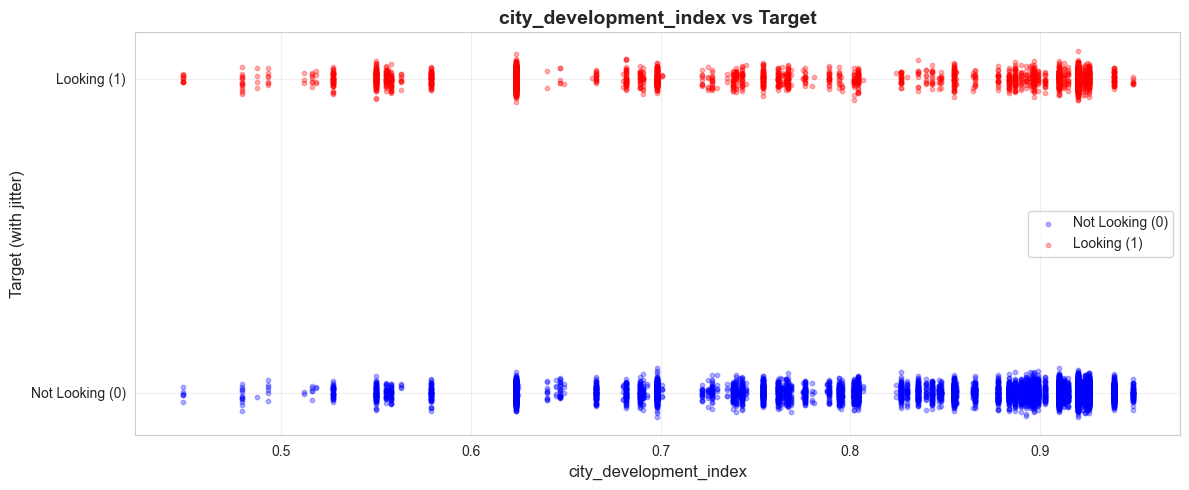

✓ Scatter plots complete

Interpretation
- Look for seperation between blue (0) and red (1) points
- Features with clear seperation are better predictors
- city_development_index shows some seperation (confirmed by -0.34 correlation)
- training_hours shows minimal seperation (very weak correlation)


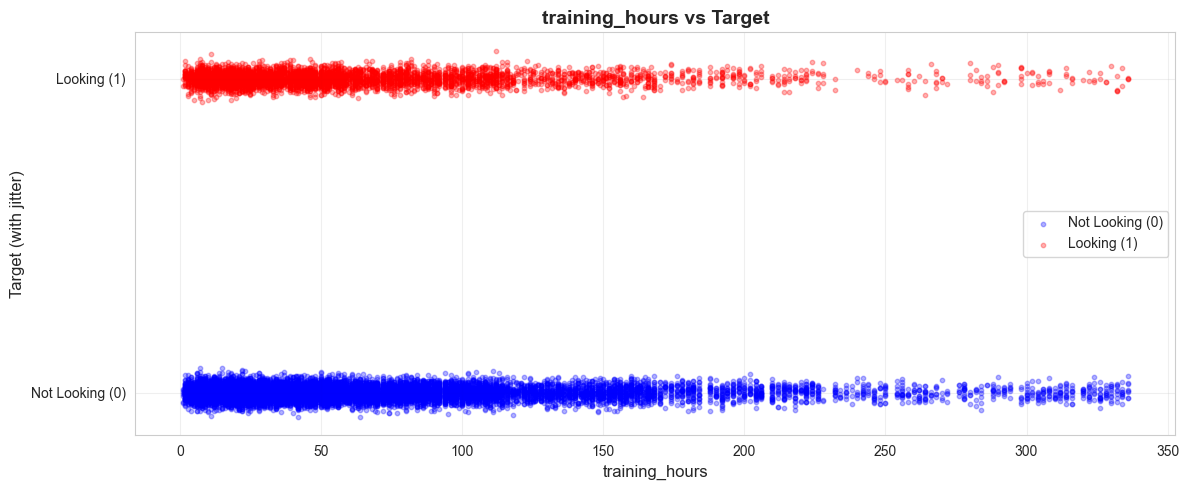

✓ Scatter plots complete

Interpretation
- Look for seperation between blue (0) and red (1) points
- Features with clear seperation are better predictors
- city_development_index shows some seperation (confirmed by -0.34 correlation)
- training_hours shows minimal seperation (very weak correlation)


In [92]:
# Create scatter plots for numerical features vs target
# Exclude ID Columns as they have no predective relationship
numerical_for_scatter = [col for col in numerical_cols if col not in ['Unnamed: 0', 'rec_num', 'enrollee_id', 'city_development_matrics', 'target']]

print(f"Creating scatter plots for {len(numerical_for_scatter)} numerical features vs target..")
print("="*80)

for col in numerical_for_scatter:
    plt.figure(figsize=(12,5))

    # Seperate data by target value
    target_0 = df[df['target'] == 0][col].dropna()
    target_1 = df[df['target'] == 1][col].dropna()

    # Create scatter plot with jitter for better visibility
    np.random.seed(42)
    jitter_0 = np.random.normal(0, 0.02, len(target_0))
    jitter_1 = np.random.normal(1, 0.02, len(target_1))

    plt.scatter(target_0, jitter_0, alpha=0.3, s=10, c='blue', label='Not Looking (0)')
    plt.scatter(target_1, jitter_1, alpha=0.3, s=10, c='red', label='Looking (1)')

    plt.xlabel(col, fontsize=12)
    plt.ylabel('Target (with jitter)', fontsize=12)
    plt.yticks([0, 1], ['Not Looking (0)', 'Looking (1)'])
    plt.title(f'{col} vs Target', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("="*80)
    print("✓ Scatter plots complete")
    print("\nInterpretation")
    print("- Look for seperation between blue (0) and red (1) points")
    print("- Features with clear seperation are better predictors")
    print("- city_development_index shows some seperation (confirmed by -0.34 correlation)")
    print("- training_hours shows minimal seperation (very weak correlation)")

## F. Outliers (5 pts)
In this section, we will use boxplots and statistical methods to detect outliers in numerical features and discus their implications

### F.1 Box Plots for Outlier Detection (2 pts)
Using box plot to visually identify outliers in numerical features

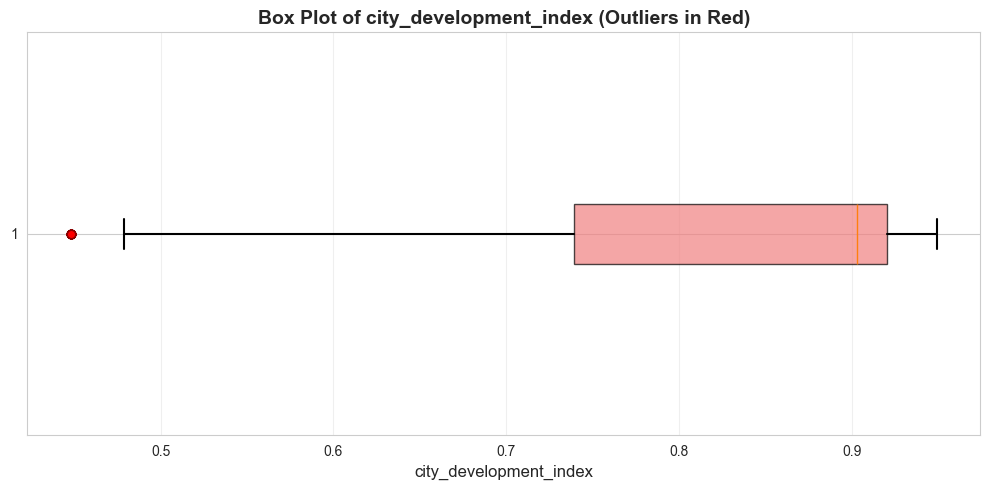

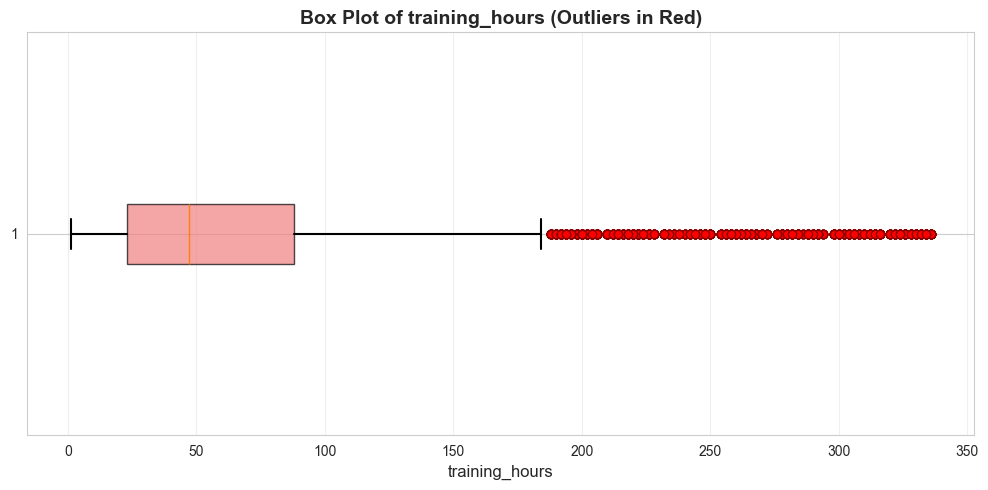

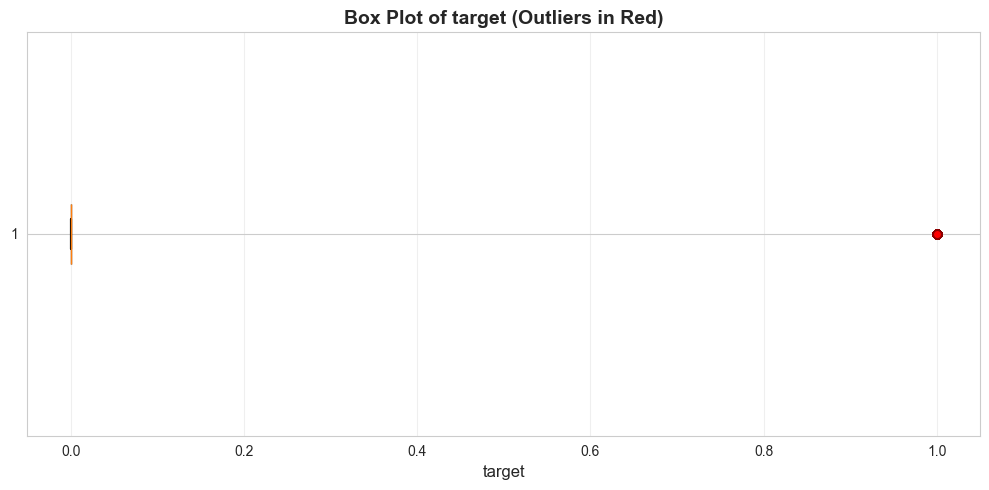

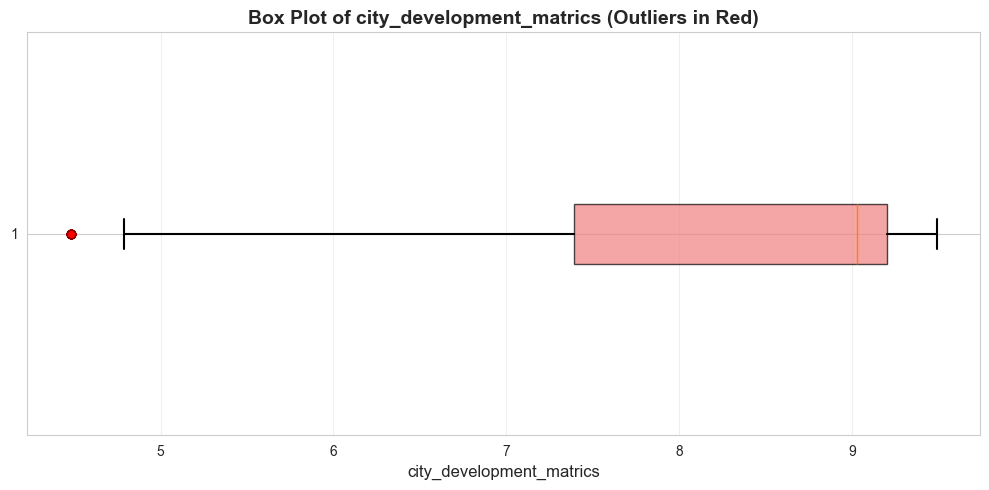

In [93]:
# Create box plots for numerical features to identify outliers
# Skip ID columns as they're not meaningful for outlier detection
numerical_for_outliers = [col for col in numerical_cols if col not in ['Unnamed: 0', 'rec_num', 'enrollee_id']]

for col in numerical_for_outliers:
    plt.figure(figsize=(10,5))

    # Create box plot
    plt.boxplot(df[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='lightcoral', color='black', alpha=0.7), whiskerprops=dict(color='black', linewidth=1.5), capprops=dict(color='black', linewidth=1.5), flierprops=dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none', markeredgecolor='darkred'))

    plt.xlabel(col, fontsize=12)
    plt.title(f'Box Plot of {col} (Outliers in Red)', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### F.2 Interpretation and Discussion (3 pts)
The boxplots and IQR analysis reveal important patterns in the numerical features. Training hours shows the most significant outliers (5.16%), representing candidates with extreme training investments (200-336 hours). The target vairiable's 22.44% "outliers" are actually missing values identifies in section B. City development features show minimal outliers (0.09%), indicating stable, well-measured data. These outliers in training-hours are valid data points and should be retained for modeling.

In [94]:
# Calculate outliers using IQR method for each numerical feature
print("Outlier Detection Using IQR method:")
print("="*80)

outlier_summary = []

for col in numerical_for_outliers:
    # Calculate Q1, Q3 and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    # Store Results 
    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Percentage': outlier_percentage
    })

    print(f"\n{col}:")
    print(f" Q1 (25th percentile): {Q1: .2f}")
    print(f" Q3 (75th Percentile): {Q1: .2f}")
    print(f" Outliers Detected: {outlier_count} ({outlier_percentage: .2f}%)")

# Create summary Dataframe
outlier_df = pd.DataFrame(outlier_summary)
print("\n" + "="*80)
print("Summary Table of Outliers:")
print("="*80)
display(outlier_df)
    

Outlier Detection Using IQR method:

city_development_index:
 Q1 (25th percentile):  0.74
 Q3 (75th Percentile):  0.74
 Outliers Detected: 19 ( 0.09%)

training_hours:
 Q1 (25th percentile):  23.00
 Q3 (75th Percentile):  23.00
 Outliers Detected: 1099 ( 5.16%)

target:
 Q1 (25th percentile):  0.00
 Q3 (75th Percentile):  0.00
 Outliers Detected: 4777 ( 22.44%)

city_development_matrics:
 Q1 (25th percentile):  7.39
 Q3 (75th Percentile):  7.39
 Outliers Detected: 19 ( 0.09%)

Summary Table of Outliers:


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Percentage
0,city_development_index,0.739,0.92,0.181,0.4675,1.1915,0.089256
1,training_hours,23.000,88.00,65.000,-74.5000,185.5000,5.162775
2,target,0.000,0.00,0.000,0.0000,0.0000,22.440926
3,city_development_matrics,7.390,9.20,1.810,4.6750,11.9150,0.089256


## G. Experience Categorization (5 pts)
In this Section, we will analyze the experience feature and categorize it into meaningful groups for better analysis and modeling.

### G.1 Identify Different Values in Experience Feature (2 pt)
Examining the unique values and distribution of the experience feature.

Unique Values in 'experience' Column:
experience
1       605
10     1081
11      750
12      546
13      453
14      641
15      745
16      576
17      378
18      306
19      333
2      1255
20      167
3      1508
4      1548
5      1593
6      1346
7      1144
8       884
9      1093
<1      596
>20    3669
Name: count, dtype: int64

Total unique values: 22
Total missing values: 70


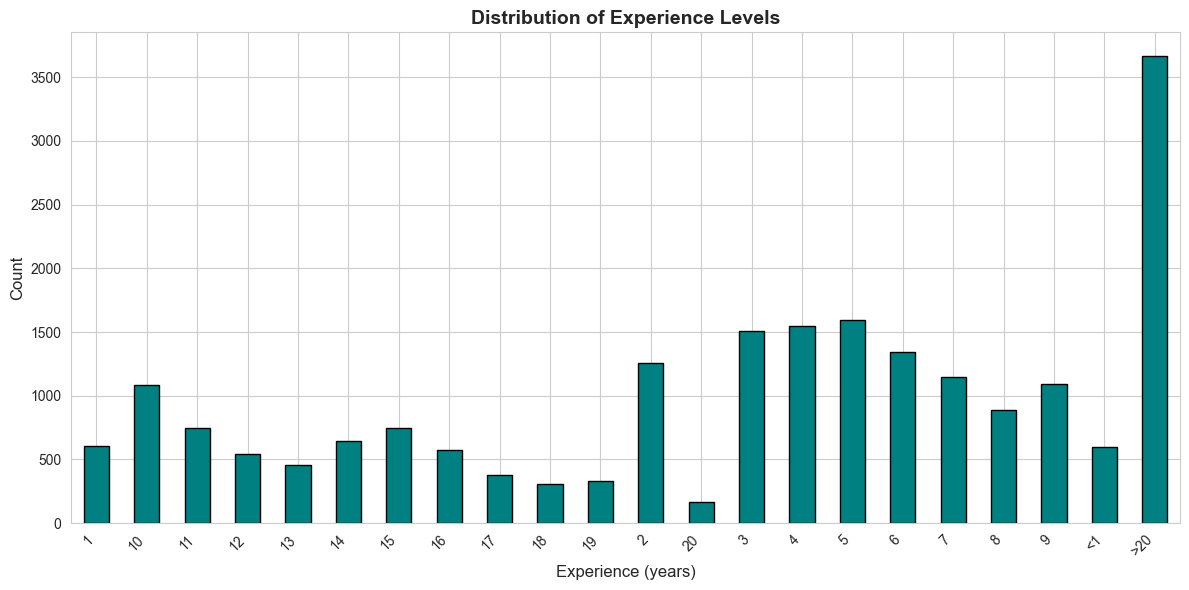

In [95]:
# Display unique vlaues in experience column
print("Unique Values in 'experience' Column:")
print("="*80)

# Get Value counts sorted by experience level
experience_counts = df['experience'].value_counts().sort_index()
print(experience_counts)

print("\n" + "="*80)
print(f"Total unique values: {df['experience'].nunique()}")
print(f"Total missing values: {df['experience'].isna().sum()}")

# Visualizing Distribution
plt.figure(figsize=(12,6))
experience_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.xlabel('Experience (years)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Experience Levels', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### G.2 Categorize Experience into Three Groups (2 pts)
Creating 3 experience categories: 0 (Entry-level), 1 (Mid-level), and 2 (Senior-level)
Categorization logic:
- Group 0 (Entry-level): 0-5 years of experience
    - includes: < 1 years to 5 years >
    - Fresh graduates and early career professionals
- Group 1 (Mid-level): 6-15 years of experience
    - Includes: < 6 years to 15 years > of experience
    - Experienced professionals with established careers
- Group 2 (Senior-level): 16+ years of experience
    - Includes: < 16 years of experience
    - Senior professionals and isdustry vetrans

Experience categorization Results
experience_category
0.0    7105
1.0    8683
2.0    5429
Name: count, dtype: int64

Distribution by Category:
    Category 0.0 (Entry-level (0-5 years)): 7105 ( 33.38%)
    Category 1.0 (Mid-level (6-15 years)): 8683 ( 40.79%)
    Category 2.0 (Senior-level (16+ years)): 5429 ( 25.50%)


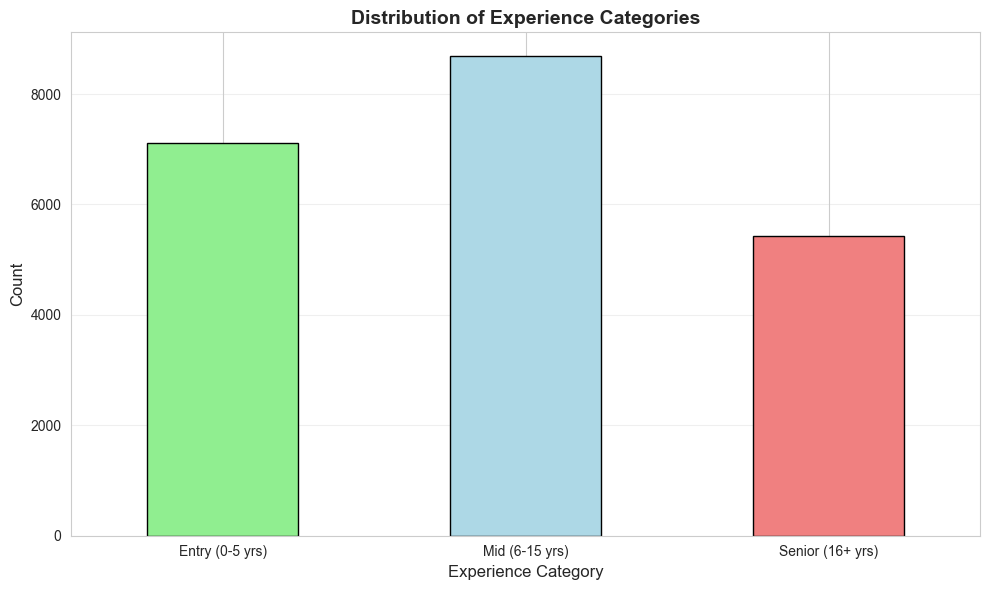

In [96]:
# Create categorization function
def categorize_experience(exp):
    """
    Categorize experience into three groups:
    0 = Entry-level (0-5 years)
    1 = Mid-level (6-15 years)
    2 = Senior-level (16+ years)
    """
    if pd.isna(exp):
        return None
    try:
        exp_str = str(exp).strip()

        # handle Special Cases
        if exp_str == '<1':
            # Entry Level
            return 0
        elif exp_str == '>20':
            # Senior -level
            return 2
        else:
            # Convert into interger
            exp_num = int(exp_str)

            if exp_num <= 5:
                # Entry level (0-5 years)
                return 0
            elif exp_num <= 15:
                # Mid - Level (6-15 years)
                return 1
            else:
                # Senior-level
                return 2
    except:
        return None
    
# Apply Categorization
df['experience_category'] = df['experience'].apply(categorize_experience)

# Display results
print("Experience categorization Results")
print("="*80)
category_counts = df['experience_category'].value_counts().sort_index()
print(category_counts)

print("\n" + "="*80)
print("Distribution by Category:")
for cat, count in category_counts.items():
    percentage = (count / len(df)) * 100
    if cat == 0:
        label = "Entry-level (0-5 years)"
    elif cat == 1:
        label = "Mid-level (6-15 years)"
    elif cat == 2:
        label = "Senior-level (16+ years)"
    else:
        label = "Unknown"
    print(f"    Category {cat} ({label}): {count} ({percentage: .2f}%)")

# Visulaize categorized distribution
plt.figure(figsize=(10,6))
category_counts.plot(kind='bar', color =['lightgreen', 'lightblue', 'lightcoral'], edgecolor='black')
plt.xlabel('Experience Category', fontsize=12)
plt.ylabel('Count',fontsize=12)
plt.title('Distribution of Experience Categories', fontsize=14, fontweight='bold')
plt.xticks([0,1,2], ['Entry (0-5 yrs)', 'Mid (6-15 yrs)', 'Senior (16+ yrs)'], rotation = 0)
plt.grid(axis='y', alpha =0.3)
plt.tight_layout()
plt.show()
    

### G.3 Explanation of Categorization Logic (1 pt)
rationale for Three-group Categorization
1. Group 0 - Entry-level (0-5 years):
    - Represents early-career professionals and recent graduates
    - These candidates are typically establishing their careers and building foundational skills
    - May be more likely to explore different oppourtunities and change jobs frequently
    - Includes the special case < 1 year of experience
2. Group 1 - Mid-level (6-15 years):
    - Represents experienced professionals with established skills
    - This group has significant industry knowledge but may still seek career advancement
    - often at a stage where they consider moves for better positions or compensation
    - Largest segment representing core working professionals
3. Group 2 - Senior-level (16+ years):
    - Represents seasoned professionals and industry veterans
    - These candidates have extensive experience and specialized expertise
    - May be more selective about job changes due to established positions
    - Includes the special case '>20' years of experience

4. why does this Categorization matter?
    - Simplifies Analysis: Reduces 21 unique experience values to 3 meaningful categorie
    - Career Stage Alignment: groups align with typical career progression
    - Modeling Benefits: Categorical feature easier to use in machine learning models
    - Interpretablitily: its clear, intuitive categories for learning and business understanding

## H. Summary and Discussion (15 pts)
After completing exploratory data analysis on 21,287 candidate records, here are the critical findings and next steps for building a job change prediction model.

Key Findings:

- Dataset Overview:
    - 21,287 candidates across 18 features (7 numerical, 11 categorical)
    - Target: 75% staying vs 25% looking for job change (class imbalance)
    - Critical data quality issue: 10% missing in target variable
- Strongest Predictor:
    - city_development_index shows -0.34 correlation with target
    - Candidates from less developed cities are MORE likely to seek job changes
- Data Quality Issues:
    - High missingness: company features (31%) and gender (23.6%)
    - Correlated missingness: company_type and company_size missing together
    - Distribution skewness: training_hours strongly right-skewed

Next Course of Action:
1. Remove Records:
    - Delete 2,129 rows where target is missing (cannot use for supervised learning)
    - Final usable dataset: ~19,158 rows
2. Remove Columns:
    - Drop city_development_matrics (redundant - perfect correlation with city_development_index)
    - Drop Unnamed: 0 and rec_num (just row indices)
    - Drop enrollee_id (ID column, no predictive value)
3. Transform Distribution:
    - training_hours: Right-skewed → apply log(training_hours + 1) if using linear models
    - For Tree based models (Random forest, XGBoost): keep original since they handle skewness naturally
4. Handle Missing Values:
    - company_type & company_size: Create "Not_disclosed" category
    - gender: Create "Unknown" category
    - major_discipline: Create "No_Major" category
    - Low-missingness features: Mode imputation
5. Rebalance Data (class imbalance):
    - Problem: 75-25 class split will bias the model toward predicting majority class
    - Rebalancing Options:
        - option 1: use class_weight='balanced' in random forest/XGBoost
        - option 2: SMOTE (synthetic minority oversampling) if option 1 gives poor results
        - option 3: Stratified train-test split to maintain class distribution
6. Modeling Approach:
    - Start with random forest since it handles mixed data types, outliers and skewness
    - use Stratified 5-fold cross-validate
    - Evaluate with F1-score and AUC-ROC (NOT accuaracy due to class imbalance)
    - Try XGBoost if Random Forest performance is insufficient

Other Findings:
- Outliers in training_hours (5.16%) are valid extreme values - suggested to keep
- Experience successfully categorized into 3 groups (Entry/Mid/Senior)
- High-cardinality city feature (123 values) needs target encoding
- Weak linear correlations suggest non-linear relationships are important

Expected Outcome:
After preprocessing, the ~19,158 usable samples with proper class balancing should achieve:
- F1-Score: >0.60
- AUC-ROC: >0.70
- Better than naive baseline (always predicting majority class)